# SVGP over Southeast Asia

The Laos fit had 41 events to identify a three-dimensional field, and the field won every time. This is the same model over the region: 37 times the events, 20 times the ground.

In [1]:
# Reload the sidecar on every cell, and nothing else. A pytensor checkout that moves under a
# blanket autoreload re-imports its rewrite modules, which register themselves a second time and
# leave the graph database corrupt; naming one module keeps that out of reach.
%load_ext autoreload
%autoreload 1
%aimport svgp_support

# Set before anything builds a graph: PyMC reads floatX when it makes a model's value variables,
# so this is the one place precision is chosen.
#
# The whitened solve loses about cond(K(Z, Z)) * eps of relative precision, which in single leaves
# the gradient about twenty degrees off in a space of thirty thousand dimensions. A minibatch
# carries a sampling noise of its own, a few hundred, so single costs Adam nothing and MLX runs it
# in minutes; a quasi-Newton pass has no other noise and cannot use a gradient that wrong. Single
# for finding the basin, double for resolving it, and MLX has no float64 on the GPU.
import pytensor

pytensor.config.floatX = "float32"

import re
import time

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import mlx.core as mx
import numpy as np
import pandas as pd
import polars as pl
import preliz as pz
import ptgp
import pytensor.tensor as pt

from matplotlib.colors import LogNorm
from ptgp.inducing import InducingVariables, compute_inducing_diagnostics, greedy_variance_init
from ptgp.kernels import Matern32

from climate_risk.config.registry import load_place
from climate_risk.data.gadm import load_units_in_country
from climate_risk.data.ghsl import population_on_cells
from climate_risk.data.model_frame import event_windows
from climate_risk.data.placement import resolve_location_text
from climate_risk.data_functions.emdat_processing import event_filter, event_geography, load_emdat_events
from climate_risk.data_functions.rivers_data_loader import load_rivers_data
from climate_risk.data_functions.shapefiles_data_loader import load_place_boundary, load_shapefile
from climate_risk.geo.crs import to_km
from climate_risk.geo.distance import get_distance_to
from climate_risk.geo.raster import assign_cells_to_units, build_cell_grid
from climate_risk.models.aggregation import build_aggregation, build_aggregation_from_overlaps
from climate_risk.plotting import configure_plot_style
from svgp_support import (
    RIVER_FLOW,
    SPATIAL_TEMPORAL_DIMS,
    TO_COAST,
    TO_RIVER,
    YEAR,
    Lattice,
    annealed_adam,
    build_model_2,
    fit_field,
    fit_minibatch,
    load_fit,
    place_inducing,
    plot_country,
    save_fit,
    select_inducing,
    standardized,
)

FLOATX = pytensor.config.floatX

pz.rcParams["plots.show_plot"] = False
configure_plot_style()

In [2]:
CACHE = (Path.cwd().parents[1] if Path.cwd().name == "geo_damage_model" else Path.cwd()) / "data"
FITS_DIR = Path.cwd() / "fits"

PLACE_KEY = "sea"
RESOLUTION_KM = 10.0
EPOCH = 2020

# The administrative level the quadrature atoms are taken at.
ATOM_LEVEL = 2

# Floods and storms, which are the hazards distance to river and distance to coast describe. The
# spelling is the wire value EM-DAT processing writes.
HAZARD_CLASS = "Hydrometereological"

place = load_place(PLACE_KEY)
place.name, place.members

('Southeast Asia',
 ('MMR', 'THA', 'LAO', 'KHM', 'VNM', 'IDN', 'MYS', 'PHL', 'TLS'))

## The grid

One row per country, so a cell knows which one it sits in and an unplaced event is observed through its own country rather than the whole region.

In [3]:
boundary = load_place_boundary(place, CACHE)
grid = build_cell_grid(boundary, resolution_km=RESOLUTION_KM)
lon, lat = grid.cells["lon"].to_numpy(), grid.cells["lat"].to_numpy()

people = population_on_cells(grid, EPOCH, CACHE)

pd.Series(
    {
        "countries": float(grid.cells["ISO_A3"].nunique()),
        "cells": float(len(grid.cells)),
        "people (millions)": people.sum() / 1e6,
    },
    name="value",
).to_frame().round(1)

,value
countries,9.00
cells,50667.00
people (millions),642.00


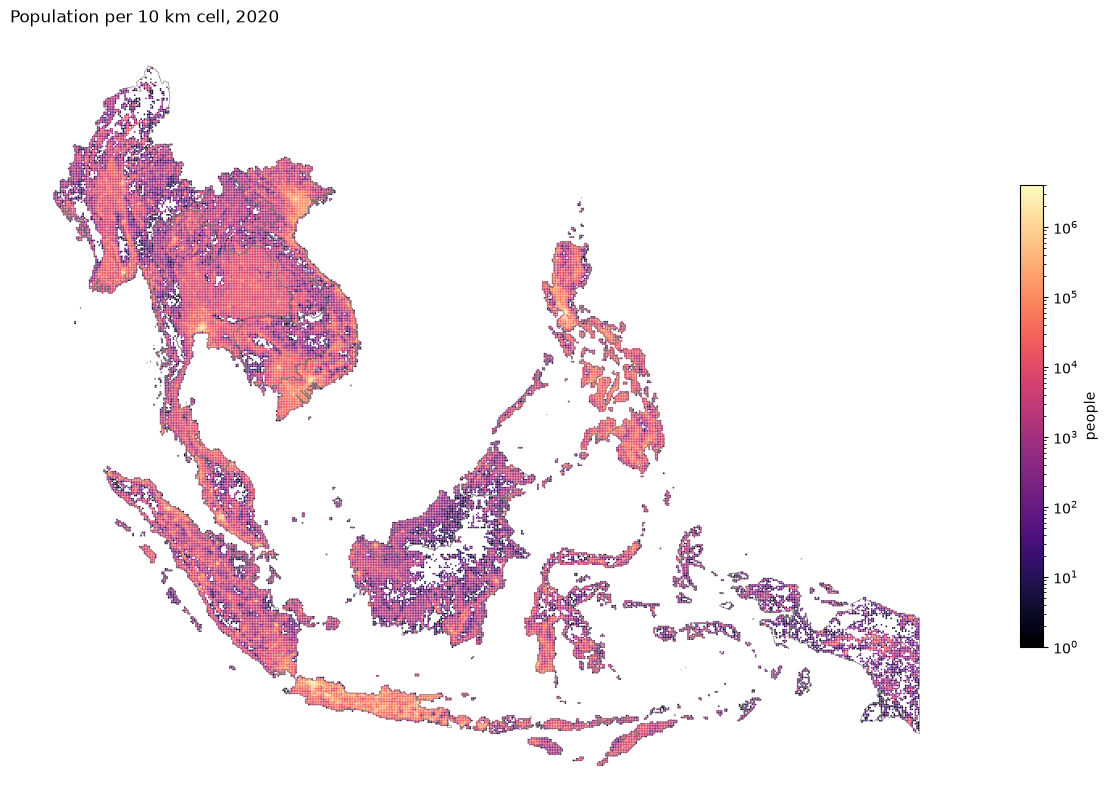

In [6]:
figure, ax = plt.subplots(figsize=(13, 8))

# Scatter rather than GeoDataFrame.plot: fifty thousand points go through geopandas one geometry at
# a time, and subsampling instead would drop the small islands.
people_layer = ax.scatter(lon, lat, c=people, s=1.5, cmap="magma", norm=LogNorm(vmin=1), linewidths=0)
boundary.boundary.plot(ax=ax, color="0.45", linewidth=0.4)

ax.set_title(f"Population per {RESOLUTION_KM:.0f} km cell, {EPOCH}", loc="left")
ax.set_aspect("equal")
ax.set_axis_off()
figure.colorbar(people_layer, ax=ax, label="people", shrink=0.6)
plt.show()

## What the model sees

Population is the exposure the operator weights by; the distances are the covariates the linear predictor gets. Distance to coast meant something different over a landlocked country than it does over an archipelago.

In [4]:
rivers = load_rivers_data(CACHE)
coastline = load_shapefile("coastline", CACHE)

# The rivers and coastlines are global and carry meter-scale detail. Neither is worth measuring
# against here: the region is a fraction of the world, and a cell is 10 km wide, so coastline wiggle
# below half a kilometer cannot move which cell is nearest what. The margin is far past the largest
# distance in the region, so clipping cannot change an answer.
margin, simplify_degrees = 12.0, 0.5 / 111.0

west, south, east, north = grid.cells.total_bounds
longitudes = slice(west - margin, east + margin)
latitudes = slice(south - margin, north + margin)

# Simplified in place rather than through the GeoSeries the accessor returns, which would drop the
# discharge column along with every other attribute.
nearby_rivers = rivers.cx[longitudes, latitudes].copy()
nearby_rivers["geometry"] = nearby_rivers.simplify(simplify_degrees)
nearby_coast = coastline.cx[longitudes, latitudes].boundary.simplify(simplify_degrees)

# A river is not a river: discharge spans four orders of magnitude, and being a kilometer from a
# tributary is not being a kilometer from the Mekong. The nearest reach's own discharge comes
# across so the model sees how far and how big together.
nearest_river = get_distance_to(nearby_rivers, points=grid.cells, return_columns=["DIS_AV_CMS"])
to_river = to_km(nearest_river["distance_to_closest"])
river_flow = nearest_river["DIS_AV_CMS"]

to_coast = to_km(get_distance_to(nearby_coast, points=grid.cells)["distance_to_closest"])

pd.DataFrame(
    {
        "km to river": to_river.to_numpy(),
        "km to coast": to_coast.to_numpy(),
        "nearest river m3/s": river_flow.to_numpy(),
    }
).describe().loc[["min", "50%", "max"]].round(1)

,km to river,km to coast,nearest river m3/s
min,0.00,0.00,100.00
50%,29.20,60.10,159.90
max,703.40,999.50,17182.40


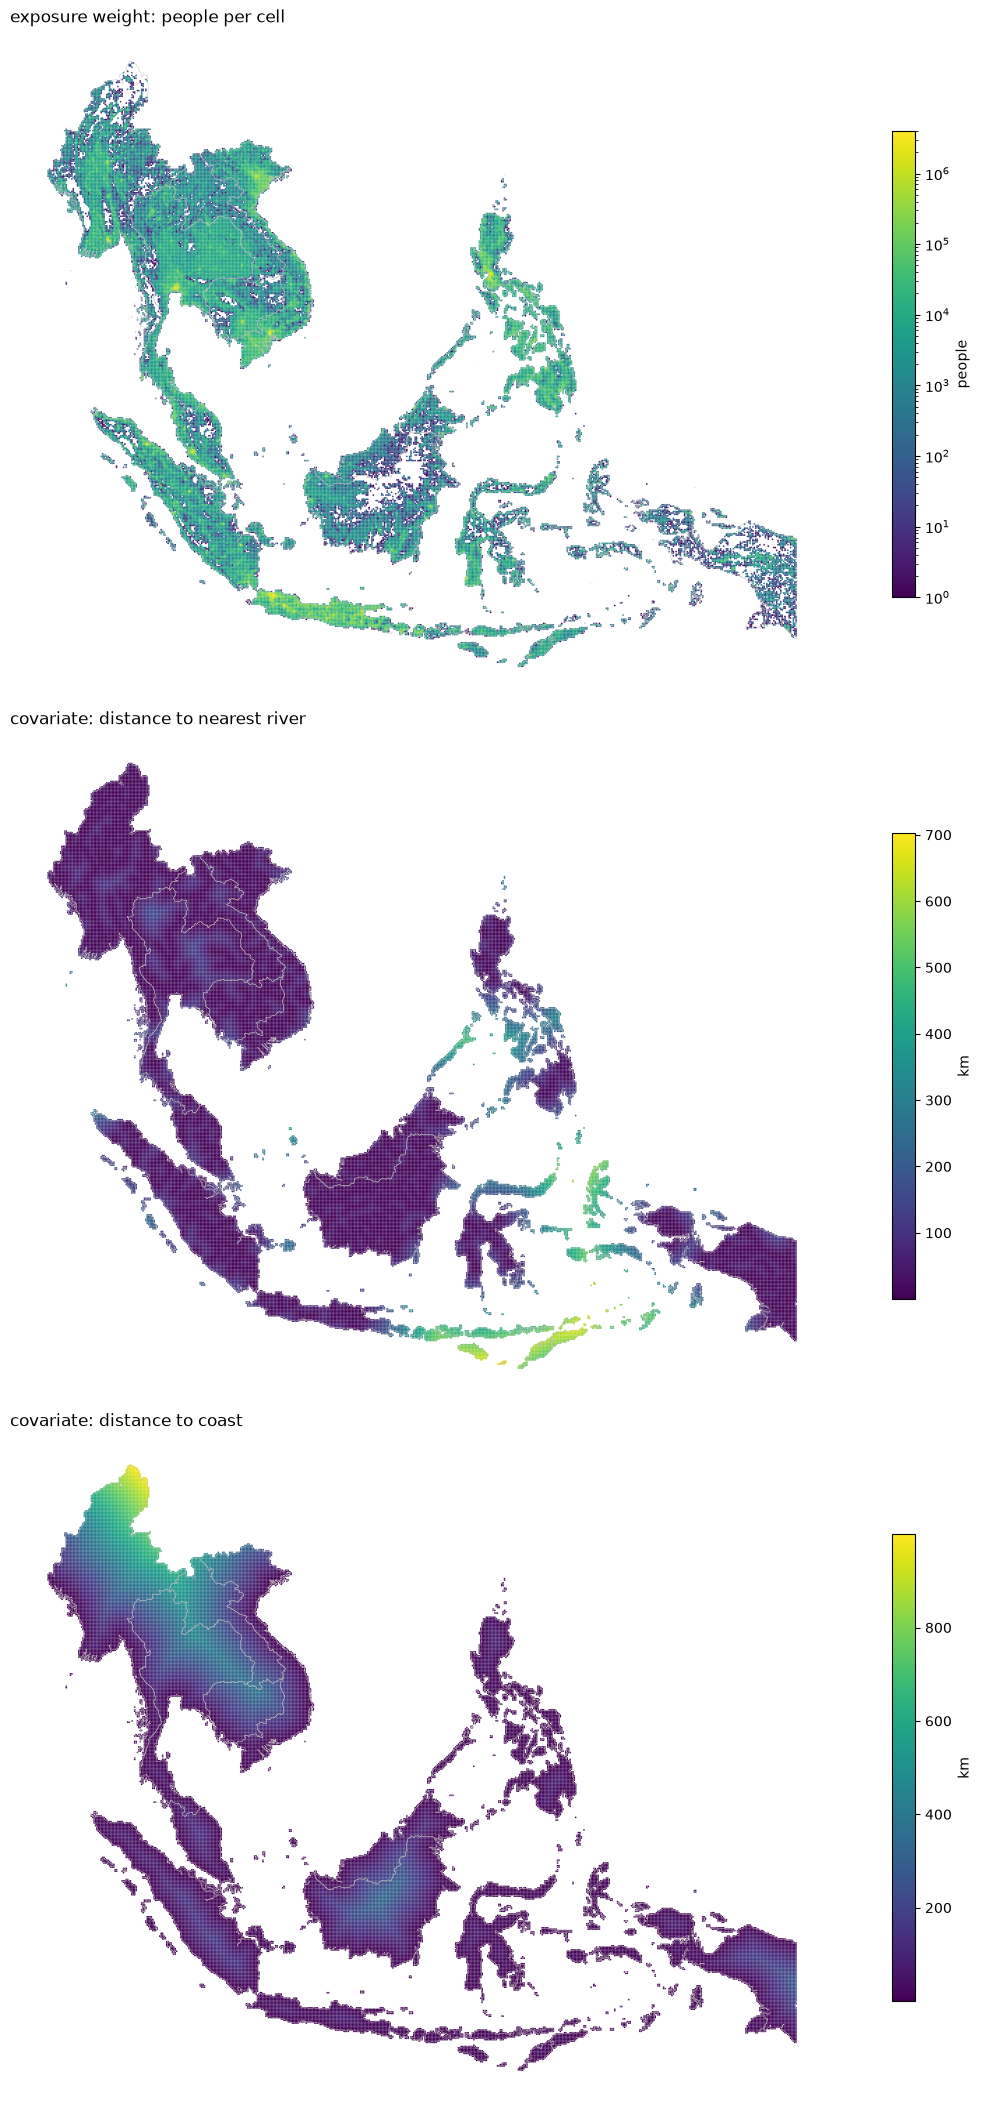

In [8]:
panels = [
    ("exposure weight: people per cell", people, LogNorm(vmin=1), "people"),
    ("covariate: distance to nearest river", to_river.to_numpy(), None, "km"),
    ("covariate: distance to coast", to_coast.to_numpy(), None, "km"),
]

figure, axes = plt.subplots(3, 1, figsize=(13, 21))

for ax, (title, values, norm, unit) in zip(axes, panels, strict=True):
    value_layer = ax.scatter(lon, lat, c=values, s=1.5, cmap="viridis", norm=norm, linewidths=0)
    boundary.boundary.plot(ax=ax, color="0.75", linewidth=0.3)

    ax.set_title(title, loc="left")
    ax.set_aspect("equal")
    ax.set_axis_off()
    figure.colorbar(value_layer, ax=ax, label=unit, shrink=0.7)

plt.show()

## Events and their windows

Each event is one observation, seen through whatever units its sources reached. An event no source placed inside a unit is observed through its own country, which over a region means one country and not the whole of it.

In [5]:
workbook = load_emdat_events(CACHE)
events = workbook.filter(
    event_filter(place.events)
    & pl.col("ISO").is_in(list(place.members))
    & (pl.col("disaster_class") == HAZARD_CLASS)
)

from_text, text_resolution = resolve_location_text(events, CACHE)
geography = event_geography(events, from_text=from_text, text_resolution=text_resolution)

windows = event_windows(events, geography)
windows.group_by("ISO").len().sort("len", descending=True).to_pandas().set_index("ISO")

,len
ISO,
PHL,502
IDN,355
VNM,258
THA,161
MYS,89
MMR,61
LAO,41
KHM,35
TLS,7


In [6]:
COVARIATE_NAMES = ["log km to river", "log km to coast", "log m3/s of nearest river"]

## Admin units as the unit of analysis

An event's window is a union of administrative units, never an arbitrary shape, so making those units the quadrature atoms makes every window exact rather than approximated by whichever cells it happens to cover. It also removes the country-sized rows: Indonesia's country-tier events reach 21,786 cells but only 502 second-level units.

The grid does not go away. It is what carries population and the distance covariates, and it is used once to aggregate those onto the units: population sums, covariates average under it, and each unit is represented at its population-weighted center, which is the point an exposure-weighted integral is most nearly equal to.

In [7]:
units = pd.concat(
    [load_units_in_country(iso=iso, level=ATOM_LEVEL, cache_dir=CACHE) for iso in place.members],
    ignore_index=True,
)
units = gpd.GeoDataFrame(units, crs="EPSG:4326")

# Area is the measure the intensity is integrated against, so it is taken from the unit's own
# geometry under an equal-area projection. PROJECTED_CRS is World Mercator, which is conformal and
# inflates area by the square of the secant of the latitude -- across this region that runs from
# true at the equator to nearly a third too large over northern Myanmar.
EQUAL_AREA_CRS = "EPSG:6933"

units["area_km2"] = units.to_crs(EQUAL_AREA_CRS).area / 1e6

# The grid is the integration mesh: a cell's share of a unit carries that share of its population,
# and the covariates come across as the average the population sees rather than the average acre.
coverage = assign_cells_to_units(grid, units)
cell_of_overlap = grid.column_of_cell(coverage["cell_id"].to_numpy())

# A coastal cell is cut from the world shapefile and the units come from GADM, whose coastline is
# tighter, so its shares sum to less than one and that much population would be dropped. Those
# cells sit a median of 2.5 km from the sea and hold a sixth of the region's people, so the
# shortfall is not spread evenly: renormalizing puts a cell's people on the land it does reach.
covered = np.zeros(len(grid.cells))
np.add.at(covered, cell_of_overlap, coverage["coverage"].to_numpy())
share = coverage["coverage"].to_numpy() / covered[cell_of_overlap] * people[cell_of_overlap]

CARRIED_COLUMNS = ("lon", "lat", "to_river", "to_coast", "river_flow")

carried = pd.DataFrame(
    {
        "gid": coverage["gid"].to_numpy(),
        "people": share,
        "lon": share * lon[cell_of_overlap],
        "lat": share * lat[cell_of_overlap],
        "to_river": share * to_river.to_numpy()[cell_of_overlap],
        "to_coast": share * to_coast.to_numpy()[cell_of_overlap],
        "river_flow": share * river_flow.to_numpy()[cell_of_overlap],
    }
).groupby("gid", as_index=False).sum()

# A unit with no population has no exposure to weight by and no center to speak of.
atoms = carried[carried["people"] > 0].reset_index(drop=True)
for column in CARRIED_COLUMNS:
    atoms[column] /= atoms["people"]

# Area belongs to the unit whole, so it joins on the id rather than being summed through the grid.
atoms = atoms.merge(units[["gid", "area_km2"]].drop_duplicates("gid"), on="gid", how="left")

pd.Series(
    {
        f"ADM{ATOM_LEVEL} units in the region": float(len(units)),
        "units the grid reaches": float(len(atoms)),
        "population carried (millions)": atoms["people"].sum() / 1e6,
        "population on the grid (millions)": people.sum() / 1e6,
        "carried (%)": 100 * atoms["people"].sum() / people.sum(),
        "area carried (million km2)": atoms["area_km2"].sum() / 1e6,
        "units missing an area": float(atoms["area_km2"].isna().sum()),
        "median unit area (km2)": float(atoms["area_km2"].median()),
        "median people per km2": float((atoms["people"] / atoms["area_km2"]).median()),
    },
    name="value",
).to_frame().round(2)

,value
ADM2 units in the region,4400.00
units the grid reaches,4387.00
population carried (millions),642.02
population on the grid (millions),642.03
carried (%),100.00
area carried (million km2),4.45
units missing an area,0.00
median unit area (km2),286.60
median people per km2,186.49


In [8]:
# GADM's version suffix is not consistent across a country's levels -- Cambodia's units are
# `KHM.1.1_2` under provinces the events name `KHM.11_1`, and some Indonesian units carry no suffix
# at all -- so ids are matched on the stem. The level comes from the geography rather than from
# counting dots, which a Ghana-style id would get wrong.
VERSION_SUFFIX = re.compile(r"_\d+$")


def stem_of(gid: str) -> str:
    return VERSION_SUFFIX.sub("", gid)


stems = [stem_of(gid) for gid in atoms["gid"]]
row_of_stem = {stem: row for row, stem in enumerate(stems)}

children_of = {}
for row, stem in enumerate(stems):
    children_of.setdefault(stem.rsplit(".", 1)[0], []).append(row)


def atoms_of(gid: str, level: int) -> list[int]:
    """Rows of ``atoms`` the named unit dissolves into."""
    stem = stem_of(gid)

    if level < ATOM_LEVEL:
        # A coarser unit is the union of the atoms beneath it; one level up is all this needs.
        return children_of.get(stem, [])

    # At or below the atoms, the unit collapses onto the atom containing it.
    ancestor = stem
    for _ in range(level - ATOM_LEVEL):
        ancestor = ancestor.rsplit(".", 1)[0]
    row = row_of_stem.get(ancestor)

    return [] if row is None else [row]


check = geography.select("gid", "admin_level").drop_nulls().unique().to_pandas()
check["atoms"] = [len(atoms_of(gid, level)) for gid, level in zip(check["gid"], check["admin_level"], strict=True)]

pd.DataFrame(
    {
        "gids named": check.groupby("admin_level").size(),
        "reaching no atom": check[check["atoms"] == 0].groupby("admin_level").size(),
        "median atoms each": check.groupby("admin_level")["atoms"].median(),
    }
).fillna(0).astype(int).rename_axis("admin level")

,gids named,reaching no atom,median atoms each
admin level,,,
1,333,0,10
2,2369,8,1
3,934,0,1
4,126,0,1


In [9]:
years = np.arange(windows["year"].min(), windows["year"].max() + 1)
n_atoms, n_years = len(atoms), len(years)
year_index = {year: position for position, year in enumerate(years)}
year_of_event = dict(zip(windows["DisNo."], windows["year"], strict=True))

atoms_by_country = {}
for row, stem in enumerate(stems):
    atoms_by_country.setdefault(stem.split(".")[0], []).append(row)

named_by_event = {}
for disno, gid, level in geography.select("DisNo.", "gid", "admin_level").drop_nulls().iter_rows():
    named_by_event.setdefault(disno, []).extend(atoms_of(gid, level))

event_ids = windows["DisNo."].to_list()
iso_of_event = dict(zip(event_ids, windows["ISO"].to_list(), strict=True))

unit_of_overlap, columns = [], []
for disno in event_ids:
    # An event no source placed inside a unit is observed through its own country, and one whose
    # sources name units that nest is observed through their union, counted once.
    reached = named_by_event.get(disno) or atoms_by_country.get(iso_of_event[disno], [])
    offset = year_index[year_of_event[disno]] * n_atoms
    for row in set(reached):
        unit_of_overlap.append(disno)
        columns.append(row + offset)

columns = np.array(columns)
atom_people = atoms["people"].to_numpy()

# Ground, not people: a hazard occurs over terrain, and the intensity is integrated against the
# measure that terrain carries. Counting the units instead would make a window's expected total
# scale with how finely GADM happened to subdivide the country under it. Population governs
# whether a hazard becomes a recorded event, which is a separate channel and enters as a covariate
# with a coefficient of its own.
atom_area = atoms["area_km2"].to_numpy()

observations = build_aggregation_from_overlaps(
    unit_of_overlap=unit_of_overlap,
    cell_of_overlap=columns,
    weights=atom_area[columns % n_atoms],
    n_cells=n_atoms * n_years,
    units=event_ids,
)

atoms_per_event = np.diff(observations.matrix.tocsr().indptr)
pd.Series(
    {
        "atoms": float(n_atoms),
        "atom-years": float(n_atoms * n_years),
        "events": float(observations.n_units),
        "events reaching no atom": float((atoms_per_event == 0).sum()),
        "atoms per event, median": float(np.median(atoms_per_event)),
        "atoms per event, 99th": float(np.quantile(atoms_per_event, 0.99)),
        "atoms per event, largest": float(atoms_per_event.max()),
    },
    name="value",
).to_frame()

,value
atoms,4387.00
atom-years,201802.00
events,1509.00
events reaching no atom,0.00
"atoms per event, median",38.00
"atoms per event, 99th",1638.00
"atoms per event, largest",1638.00


In [10]:
coordinates = np.column_stack(
    [
        np.tile(atoms["lon"].to_numpy(), n_years),
        np.tile(atoms["lat"].to_numpy(), n_years),
        np.repeat(years, n_atoms),
    ]
).astype(FLOATX)
design = np.tile(
    np.column_stack(
        [
            standardized(np.log1p(atoms["to_river"].to_numpy())),
            standardized(np.log1p(atoms["to_coast"].to_numpy())),
            standardized(np.log(atoms["river_flow"].to_numpy())),
        ]
    ),
    (n_years, 1),
).astype(FLOATX)

# Population enters the exponent with a coefficient of its own rather than the weight with an
# exponent fixed at one. The rate is sum_i area_i * people_i^beta * exp(f_i), so beta reads
# directly as the population exponent: zero is hazard over ground alone, one is the strict
# proportionality the weight used to assume. Centered rather than standardized, which leaves that
# reading intact and keeps the intercept off a twelve-log offset.
#
# Floored at one person first. A population-weighted share of a raster cell can land arbitrarily
# close to zero, and while that is a harmless weight it is a log of minus seventeen here, thirteen
# standard deviations out, which the exponent turns into an overflow the moment beta leaves zero.
POPULATION_FLOOR = 1.0

log_people = np.log(np.maximum(atom_people, POPULATION_FLOOR))
exposure = np.tile(log_people - log_people.mean(), n_years)[:, None].astype(FLOATX)

# Kernel axes first, then the axes the kernel does not see. The inducing points span the first
# group alone, and that width is what tells build_model where the linear predictor starts.
N_KERNEL_DIMS = coordinates.shape[1] + design.shape[1]

features = np.column_stack([coordinates, design, exposure]).astype(FLOATX)
weights = np.tile(atom_area, n_years).astype(FLOATX)
counts = np.ones(observations.n_units, dtype=FLOATX)

# The whole lattice in one row: the ground where nothing was recorded is the rest of this.
region = build_aggregation(unit_of_cell=["region"] * len(features), weights=weights)

pd.Series(
    {
        "atom-years": float(len(features)),
        "kernel dimensions": float(N_KERNEL_DIMS),
        "linear-predictor dimensions": float(features.shape[1] - N_KERNEL_DIMS),
        "exposure, total km2 (millions)": float(weights.sum()) / 1e6 / n_years,
        "atoms hitting the population floor": float((atom_people < POPULATION_FLOOR).sum()),
        "centered log people, most negative": float((log_people - log_people.mean()).min()),
        "features (MB)": features.nbytes / 1e6,
    },
    name="value",
).to_frame().round(2)

,value
atom-years,201802.00
kernel dimensions,6.00
linear-predictor dimensions,1.00
"exposure, total km2 (millions)",4.45
atoms hitting the population floor,1.00
"centered log people, most negative",-11.05
features (MB),5.65


In [11]:
lattice = Lattice(
    atoms=atoms,
    years=years,
    observations=observations,
    units=units,
    boundary=boundary,
    iso_of_event=iso_of_event,
    year_of_event=year_of_event,
)

pd.Series(
    {
        "atoms": float(lattice.n_atoms),
        "years": float(lattice.n_years),
        "atom-years": float(lattice.n_atoms * lattice.n_years),
        "countries": float(len(set(lattice.iso_of_atom))),
    },
    name="value",
).to_frame()

,value
atoms,4387.00
years,46.00
atom-years,201802.00
countries,9.00


## The fit

The lattice is small enough to hold whole, so the objective is exact and a quasi-Newton method can be used on it. The compile backend is an argument to `fit_field`: MLX on Apple silicon, FAST_RUN on the CPU.

## How many inducing points the field needs

The inducing points carry the whole field: whatever prior variance they fail to explain is variance the posterior cannot represent, however well the optimizer does. `tr(Kff - Q)` against `tr(Kff)` measures that directly.

The count needed depends almost entirely on the spatial lengthscale, which is the tension in this model. A flood correlates over a basin or a storm footprint, tens to low hundreds of kilometers, and the aggregated likelihood integrates the field over each window, so coarse reporting is no reason for a long lengthscale. But a short one has to be resolved.

In [12]:
# The residual is an average over the lattice, so a sample of it measures the same thing without
# building an (M, 201802) block for every count in the sweep.
DIAGNOSTIC_ROWS = 20_000

sample = np.random.default_rng(0).choice(len(features), size=DIAGNOSTIC_ROWS, replace=False)
sampled_features, sampled_weights = features[sample], weights[sample]


def variance_explained(spatial_ls, inducing_counts, *, temporal_ls=20.0, covariate_ls=2.3, amplitude=1.0):
    """
    The share of the field's prior variance a given number of inducing points can represent.

    ``tr(Kff - Q)`` against ``tr(Kff)``: whatever the inducing points fail to explain is variance
    the posterior cannot carry, however well the optimizer does.

    Parameters
    ----------
    spatial_ls : float
        Spatial lengthscale in degrees, which is what the answer is most sensitive to.
    inducing_counts : sequence of int
        Inducing point counts to try.
    temporal_ls : float, optional
        Temporal lengthscale in years. Default 20.0.
    covariate_ls : float, optional
        Covariate lengthscale in standard deviations. Default 2.3.
    amplitude : float, optional
        Amplitude of both kernel terms. Default 1.0.

    Returns
    -------
    dict
        Percentage explained, keyed by count.
    """
    kernel = amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array([spatial_ls, spatial_ls, temporal_ls], dtype=FLOATX),
        active_dims=list(range(SPATIAL_TEMPORAL_DIMS)),
    ) + amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.full(N_KERNEL_DIMS - SPATIAL_TEMPORAL_DIMS, covariate_ls, dtype=FLOATX),
        active_dims=list(range(SPATIAL_TEMPORAL_DIMS, N_KERNEL_DIMS)),
    )

    explained = {}
    for count in inducing_counts:
        health = compute_inducing_diagnostics(
            kernel, sampled_features, place_inducing(sampled_features, sampled_weights, count)
        )
        explained[count] = 100 * (1 - health.nystrom_residual / health.total_variance)

    return explained


# A lengthscale a flood can plausibly correlate over is a basin or a storm footprint, tens to low
# hundreds of kilometers. What that costs in inducing points is the constraint on using one.
pd.DataFrame(
    {
        "4.5 deg (~500 km)": variance_explained(4.5, (250, 1000, 2000, 4000)),
        "0.6 deg (~67 km)": variance_explained(0.6, (250, 1000, 2000, 4000)),
    }
).rename_axis("inducing points").round(1)

,4.5 deg (~500 km),0.6 deg (~67 km)
inducing points,,
250,92.20,58.70
1000,97.70,73.20
2000,98.90,81.90
4000,99.50,89.80


## Where the points go, not just how many

K-means places centers where the exposure is, so they crowd the cities and repeat each other. `K(Z, Z)` inherits that: near-duplicate points make near-duplicate rows, which is what drives its smallest eigenvalues below zero and forces a correction before the factorization.

Greedy conditional-variance selection takes the opposite view. It picks, at each step, the lattice point the current set explains least, which is a partial pivoted Cholesky with the max-diagonal pivot rule. The points it returns are non-redundant by construction, so the same count should explain more variance and leave a matrix that factors without help.

The percentages here are read at the prior's own hyperparameters, which are a shorter temporal lengthscale and a smaller amplitude than the sweep above used, so the two tables are not comparable count for count.

In [15]:
def prior_kernel(spatial_ls, *, temporal_ls=9.2, covariate_ls=2.3, amplitude=0.57):
    """The additive kernel at plausible hyperparameters, for judging a set of inducing points."""
    return amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array([spatial_ls, spatial_ls, temporal_ls], dtype=FLOATX),
        active_dims=list(range(SPATIAL_TEMPORAL_DIMS)),
    ) + amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.full(N_KERNEL_DIMS - SPATIAL_TEMPORAL_DIMS, covariate_ls, dtype=FLOATX),
        active_dims=list(range(SPATIAL_TEMPORAL_DIMS, N_KERNEL_DIMS)),
    )


kernel = prior_kernel(3.3)

# Compiled once and reused. The variance and the conditioning come from different places on
# purpose: the diagnostic factorizes K(Z, Z) itself, so it cannot answer whether that factorization
# would succeed, and reads it under a jitter that floors the very eigenvalue in question.
_left, _right = pt.matrix("left"), pt.matrix("right")
cross_covariance = pytensor.function([_left, _right], kernel(_left, _right))


def placement_health(points, seconds):
    """What a set of inducing points explains, and whether its ``K(Z, Z)`` factors as it stands."""
    points = np.ascontiguousarray(points, dtype=FLOATX)

    explained = compute_inducing_diagnostics(kernel, sampled_features, points)
    Kuu = np.asarray(cross_covariance(points, points), dtype=np.float64)
    eigenvalues = np.linalg.eigvalsh(Kuu)
    ridge = InducingVariables._JITTER_MARGIN * np.finfo(np.float32).eps * len(points) * np.mean(np.diag(Kuu))

    return {
        "placement (s)": seconds,
        "variance explained (%)": 100 * (1 - explained.nystrom_residual / explained.total_variance),
        "smallest eigenvalue": eigenvalues.min(),
        "condition number": eigenvalues.max() / abs(eigenvalues.min()),
        "ridge applied": ridge,
        "factors after ridge": bool(ridge + eigenvalues.min() > 0),
    }


# Greedy returns a subset of the rows it is handed, so it reads the same sample the diagnostic
# does; the fit draws a sample of the same size from the whole lattice.
comparison = {}
for count in (250, 1000, 4000):
    started = time.perf_counter()
    kmeans_Z = place_inducing(sampled_features, sampled_weights, count)
    comparison[(count, "k-means")] = placement_health(kmeans_Z, time.perf_counter() - started)

    started = time.perf_counter()
    greedy_points, _ = greedy_variance_init(sampled_features, count, kernel)
    greedy_Z = np.asarray(greedy_points.Z.eval() if hasattr(greedy_points.Z, "eval") else greedy_points.Z)
    comparison[(count, "greedy")] = placement_health(greedy_Z, time.perf_counter() - started)

pd.DataFrame(comparison).T.rename_axis(["inducing points", "placement"])

placement (s) variance explained (%)  \
inducing points placement                                        
250             k-means            0.55                  84.10   
                greedy             0.19                  81.46   
1000            k-means            2.58                  94.17   
                greedy             1.20                  95.24   
4000            k-means            9.90                  98.63   
                greedy             9.25                  99.36   

                          smallest eigenvalue condition number ridge applied  \
inducing points placement                                                      
250             k-means                  0.00         11584.03          0.00   
                greedy                   0.09           445.73          0.00   
1000            k-means                 -0.00         84019.70          0.00   
                greedy                   0.02          8456.23          0.00   
4000            k-means                 -0.01         96839.48          0.00   
                greedy                  -0.00       1004601.20          0.00   

                          factors after ridge  
inducing points placement                      
250             k-means                  True  
                greedy                   True  
1000            k-means                 False  
                greedy                   True  
4000            k-means                 False  
                greedy                   True

## What a short lengthscale costs to run

Resolving a physical lengthscale needs thousands of inducing points, and the per-step cost of that is what decides whether it is reachable. `K(Z, Z)` is decomposed every step, which is cubic in the count, while the batch work is only quadratic; measuring a few steps says which one dominates here.

In [14]:
TIMING_STEPS = 30

timings = {}
for count in (250, 1000, 4000):
    mx.clear_cache()
    mx.reset_peak_memory()

    started = time.perf_counter()
    _, timed = fit_minibatch(
        features,
        observations,
        weights,
        place_inducing(features, weights, n_inducing=count),
        mode="MLX",
        n_steps=TIMING_STEPS,
        n_windows=512,
        batch_size=100_000,
        optimizer_fn=annealed_adam(TIMING_STEPS, learning_rate=5e-3),
    )
    elapsed = time.perf_counter() - started

    timings[count] = {
        "compile + 30 steps (s)": elapsed,
        "MLX peak memory (GB)": mx.get_peak_memory() / 1e9,
        "4000 steps would take (min)": elapsed / TIMING_STEPS * 4000 / 60,
    }

pd.DataFrame(timings).T.rename_axis("inducing points").round(2)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


adam:   0%|          | 0/30 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


adam:   0%|          | 0/30 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


adam:   0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [18]:
# FAST_RUN, not MLX: L-BFGS steps further than Adam does, and a singular K(Z, Z) comes back as NaN
# under numba, which reaches the loss and gets the step rejected. MLX aborts the interpreter.
started = time.perf_counter()
final_svgp, final_result = fit_field(
    features,
    counts,
    observations,
    region,
    pipeline_inducing,
    start=adam_result,
    mode="FAST_RUN",
)
lbfgs_seconds = time.perf_counter() - started
final_trained = final_result.params

final_mean, final_variance = ptgp.predict(final_svgp, features, final_result)
final_intensity = np.exp(final_mean + final_variance / 2.0)

save_fit(
    final_result,
    "additive_adam_then_lbfgs",
    FITS_DIR,
    objective=float(final_result.result.fun),
    status=int(final_result.result.status),
    largest_gradient=float(np.abs(final_result.result.jac).max()),
    n_inducing=len(pipeline_inducing),
    floatX=FLOATX,
    mode="FAST_RUN",
    started_from="additive_adam",
    adam_wall_clock_s=adam_seconds,
    lbfgs_wall_clock_s=lbfgs_seconds,
    expected_events=float(region.aggregate(final_intensity)[0]),
)

pd.DataFrame(
    {
        "adam alone": {
            "objective": float(adam_result.result[-500:].mean()),
            "intercept": adam_trained["intercept"],
            "spatial lengthscale (deg)": adam_trained["spatial_lengthscale"],
            "temporal lengthscale (yr)": adam_trained["temporal_lengthscale"],
            "spatial amplitude": adam_trained["amplitude"],
            "covariate amplitude": adam_trained["covariate_amplitude"],
            **{
                f"lengthscale, {name} (sd)": value
                for name, value in zip(COVARIATE_NAMES, adam_trained["covariate_lengthscale"], strict=True)
            },
            "seconds": adam_seconds,
            "expected events": float(region.aggregate(adam_intensity)[0]),
        },
        "then L-BFGS": {
            "objective": float(final_result.result.fun),
            "intercept": final_trained["intercept"],
            "spatial lengthscale (deg)": final_trained["spatial_lengthscale"],
            "temporal lengthscale (yr)": final_trained["temporal_lengthscale"],
            "spatial amplitude": final_trained["amplitude"],
            "covariate amplitude": final_trained["covariate_amplitude"],
            **{
                f"lengthscale, {name} (sd)": value
                for name, value in zip(COVARIATE_NAMES, final_trained["covariate_lengthscale"], strict=True)
            },
            "seconds": lbfgs_seconds,
            "expected events": float(region.aggregate(final_intensity)[0]),
        },
    }
).round(3)

Output()

Output()

Output()

,adam alone,then L-BFGS
objective,3681.52,115.43
intercept,-16.87,-18.90
spatial lengthscale (deg),4.53,0.52
temporal lengthscale (yr),19.59,108.03
spatial amplitude,1.07,1.29
covariate amplitude,0.51,0.92
"lengthscale, log km to river (sd)",2.61,2.45
"lengthscale, log km to coast (sd)",0.86,0.69
"lengthscale, log m3/s of nearest river (sd)",1.35,1.41
seconds,352.75,118.44


## The fitted field, one country at a time

The region spans forty degrees and cannot be read at once. A country is the scale a result gets checked against, so the surface is contoured over that country's atoms and clipped to its border, with every event recorded there outlined at the union of the units it was reported through.

That outline is the ground the likelihood integrated over. Where it covers a whole country, the event says only that something happened somewhere in it.

## Minibatch

The same model under Adam on sampled batches. A sampled window's contribution is nonlinear in its own total, so it brings every atom it reaches; those atoms then enter the region term at their own weight, and the rest of the budget is drawn from the ground no window covers, carrying the scale that makes it stand for all of it.

Two things set the batch. The window term is scaled by the number of events over the number sampled, so sampling few of them puts a large multiplier on a noisy sum; windows are small, at a median of 38 atoms, so many of them fit inside the same budget and the multiplier falls. The region term is a smooth sum over the whole lattice and samples well at any size.

Sampling on a batch rather than the whole lattice is also what makes a well resolved field affordable: `K_uf` is inducing points by batch rows, so a thousand inducing points cost a fifth of a gigabyte here against three over the full lattice.

In [18]:
mx.clear_cache()
mx.reset_peak_memory()

N_INDUCING = 1000
ADAM_STEPS = 4000

# A whitened SVGP carries q_mu and the lower triangle of q_sqrt, and that count is what a step's
# norm scales with.
N_VARIATIONAL = N_INDUCING + N_INDUCING * (N_INDUCING + 1) // 2

# Selected under the prior's own hyperparameters and then frozen, which is Burt's recipe: a good
# greedy set is within noise of one optimized alongside the hyperparameters, at a fraction of the
# cost. Clustering at this count leaves K(Z, Z) indefinite in single precision.
#
# Sliced to the kernel axes: the trailing column acts on the mean, and its width is how build_model
# tells the two groups apart.
pipeline_inducing = select_inducing(features, N_INDUCING, prior_kernel(3.3))[:, :N_KERNEL_DIMS]

started = time.perf_counter()
adam_svgp, adam_result = fit_minibatch(
    features,
    observations,
    weights,
    pipeline_inducing,
    mode="MLX",
    n_steps=ADAM_STEPS,
    n_windows=512,
    batch_size=100_000,
    optimizer_fn=annealed_adam(ADAM_STEPS, learning_rate=5e-3, n_parameters=N_VARIATIONAL),
)
adam_seconds = time.perf_counter() - started
adam_trained = adam_result.params

adam_mean, adam_variance = ptgp.predict(adam_svgp, features, adam_result)
adam_intensity = np.exp(adam_mean + adam_variance / 2.0)

save_fit(
    adam_result,
    "area_exposure_beta",
    FITS_DIR,
    loss_last_500=float(adam_result.result[-500:].mean()),
    noise_last_500=float(adam_result.result[-500:].std()),
    n_inducing=N_INDUCING,
    placement="greedy conditional variance",
    exposure="area, with population as a fitted exponent",
    n_windows=512,
    batch_size=100_000,
    steps=ADAM_STEPS,
    floatX=FLOATX,
    mode="MLX",
    wall_clock_s=adam_seconds,
)

pd.Series(
    {
        "wall clock (s)": adam_seconds,
        "MLX peak memory (GB)": mx.get_peak_memory() / 1e9,
        "loss, last 500": float(adam_result.result[-500:].mean()),
        "per-step noise (sd)": float(adam_result.result[-500:].std()),
        "non-finite losses": float(np.sum(~np.isfinite(adam_result.result))),
        "population exponent (beta)": float(adam_trained["coefficients"][0]),
        "intercept": adam_trained["intercept"],
        "spatial lengthscale (deg)": adam_trained["spatial_lengthscale"],
        "temporal lengthscale (yr)": adam_trained["temporal_lengthscale"],
        "spatial amplitude": adam_trained["amplitude"],
        "covariate amplitude": adam_trained["covariate_amplitude"],
        "expected events": float(region.aggregate(adam_intensity)[0]),
        "events observed": float(observations.n_units),
    },
    name="value",
).to_frame().round(3)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced a step whose global norm reached 17.704166176355212 on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  

adam:   0%|          | 0/4000 [00:00<?, ?it/s]

,value
wall clock (s),2275.88
MLX peak memory (GB),9.38
"loss, last 500",4699.87
per-step noise (sd),118.46
non-finite losses,0.00
intercept,-16.91
spatial lengthscale (deg),3.58
temporal lengthscale (yr),25.67
spatial amplitude,1.26
covariate amplitude,0.20


In [16]:
trace = pd.Series(adam_result.result)

figure, ax = plt.subplots(figsize=(9, 4))

ax.plot(trace.index, trace, color="0.8", linewidth=0.7, label="batch")
ax.plot(trace.index, trace.rolling(50, min_periods=1).mean(), color="C0", linewidth=1.6, label="50-step mean")

ax.set_yscale("log")
ax.set_xlabel("Adam step")
ax.set_ylabel("loss")
ax.set_title("Training trace", loc="left")
ax.spines[["top", "right"]].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
figure.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=2, frameon=False)
plt.show()

NameError: name 'batch_result' is not defined

## Adam then L-BFGS

Adam finds the basin cheaply and stops at the noise floor of its own gradient estimate; the full-batch pass sees a gradient with no noise in it at all. Handing the first to the second is the whole point of having both.

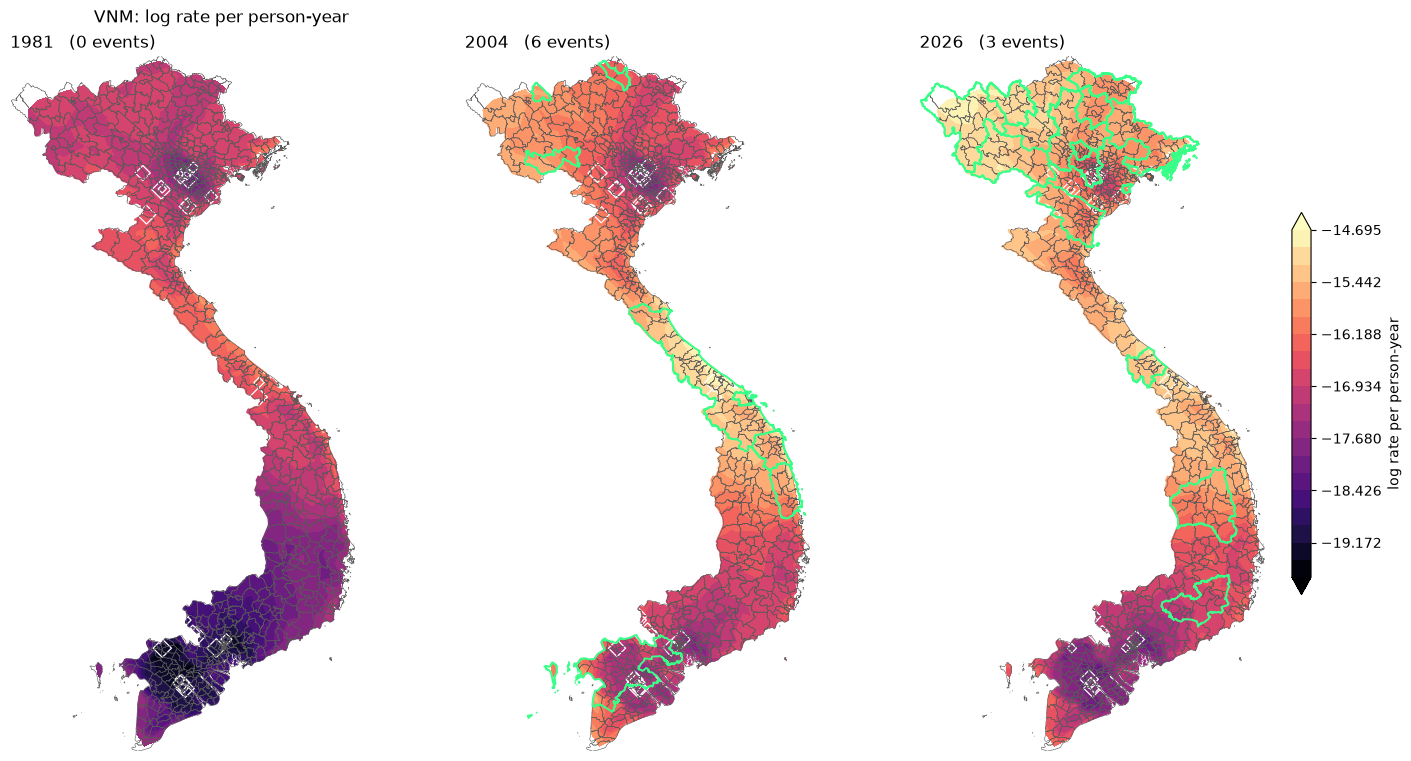

In [27]:
plot_country(lattice, "VNM", adam_intensity, pipeline_inducing, adam_trained)

## No geography

The surface over latitude and longitude was doing the work the covariates were meant to do. Distance to river, distance to coast and discharge are all smooth spatial fields, so a flexible surface over position is nearly collinear with them and wins, which is what the fitted amplitudes said: 1.32 against 0.20.

So the field is rebuilt with no geographic axes at all. Two response surfaces, one over distance to river against the river's own discharge, one over distance to coast, each crossed with time. Geography survives only as a country level, which is the resolution EM-DAT's reporting varies at and which cannot imitate a smooth covariate gradient.

Population moves out of the exposure weight, where its exponent was fixed at one, and into the linear predictor where it is fitted. The rate reads as area times people to the beta times the field.

In [19]:
country_of_atom = pd.Categorical([stem.split(".")[0] for stem in stems])
country_names = list(country_of_atom.categories)

# One indicator per country bar the first, which the intercept carries as the reference. A country
# effect is a set of offsets, so it belongs in the linear predictor; as a categorical kernel its
# gradient is a scatter-add, and the MLX backend dispatches that one wrongly.
country_dummies = (country_of_atom.codes[:, None] == np.arange(1, len(country_names))).astype(FLOATX)

# Every kernel axis standardized. The year mattered most: a Matern takes squared distances through
# |x|^2 + |y|^2 - 2xy, and at values near two thousand the first two terms are around four million,
# where single precision spaces its representable numbers a quarter apart -- against true squared
# distances of order twenty. The kernel entries came out wrong in the third decimal, which was
# enough to carry the smallest eigenvalues of K(Z, Z) below zero and take the factorization down.
#
# The scales are kept so the fit reads in the units it was posed in, and so the lengthscale priors
# carry across unchanged: standardizing an axis changes what a number on it means, not the belief.
# The country columns stay as indicators; standardizing a zero-one column has no meaning.
YEAR_ORIGIN_2, YEAR_SCALE_2 = float(np.mean(years)), float(np.std(years))
POPULATION_ORIGIN_2, POPULATION_SCALE_2 = float(np.mean(log_people)), float(np.std(log_people))

# Kernel axes first, then the axes the kernel does not see. Time is a column both Matern blocks
# read rather than an axis either owns, so a lengthscale over it is fitted once per surface.
features_2 = np.column_stack(
    [
        np.repeat((years - YEAR_ORIGIN_2) / YEAR_SCALE_2, n_atoms),
        np.tile(standardized(np.log1p(atoms["to_river"].to_numpy())), n_years),
        np.tile(standardized(np.log1p(atoms["to_coast"].to_numpy())), n_years),
        np.tile(standardized(np.log(atoms["river_flow"].to_numpy())), n_years),
        np.tile(country_dummies, (n_years, 1)),
        np.tile((log_people - POPULATION_ORIGIN_2) / POPULATION_SCALE_2, n_years)[:, None],
    ]
).astype(FLOATX)

N_KERNEL_DIMS_2 = 4

# The intervals as they were, in the units the axes now carry. The covariates were already
# standardized, so theirs is unchanged; the temporal one was in years and is divided through.
COVARIATE_BOUNDS_2 = (0.5, 5.0)
TEMPORAL_BOUNDS_2 = (2.0 / YEAR_SCALE_2, 20.0 / YEAR_SCALE_2)

pd.Series(
    {
        "atom-years": float(len(features_2)),
        "kernel dimensions": float(N_KERNEL_DIMS_2),
        "linear-predictor dimensions": float(features_2.shape[1] - N_KERNEL_DIMS_2),
        "countries": float(len(country_names)),
        "kernel columns have sd one": float(
            np.allclose(features_2[:, :N_KERNEL_DIMS_2].std(axis=0), 1.0, atol=0.02)
        ),
        "largest absolute kernel value": float(np.abs(features_2[:, :N_KERNEL_DIMS_2]).max()),
        "year scale (years per sd)": YEAR_SCALE_2,
        "temporal interval, in sd": TEMPORAL_BOUNDS_2[1],
        "rows aligned with the weights": float(len(features_2) == len(weights)),
    },
    name="value",
).to_frame().round(3)

,value
atom-years,201802.00
kernel dimensions,4.00
linear-predictor dimensions,9.00
countries,9.00
kernel columns have sd one,1.00
largest absolute kernel value,3.38
year scale (years per sd),13.28
"temporal interval, in sd",1.51
rows aligned with the weights,1.00


In [20]:
def prior_kernel_2(covariate_ls=2.3, temporal_ls=None, amplitude=0.57):
    """The two Matern surfaces at plausible hyperparameters, for judging a set of inducing points."""
    # Nine years, expressed on the standardized axis rather than in years.
    temporal_ls = 9.2 / YEAR_SCALE_2 if temporal_ls is None else temporal_ls

    return amplitude**2 * Matern32(
        input_dim=features_2.shape[1],
        ls=np.array([covariate_ls, covariate_ls, temporal_ls], dtype=FLOATX),
        active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
    ) + amplitude**2 * Matern32(
        input_dim=features_2.shape[1],
        ls=np.array([covariate_ls, temporal_ls], dtype=FLOATX),
        active_dims=[TO_COAST, YEAR],
    )


# The country level is left out of the placement kernel: it takes nine values, so it cannot drive
# which rows are redundant, and the codes come along on whichever rows greedy returns.
DIAGNOSTIC_ROWS_2 = 20_000

sample_2 = np.random.default_rng(0).choice(len(features_2), size=DIAGNOSTIC_ROWS_2, replace=False)
sampled_2 = features_2[sample_2]

# The check the sparse runs never had: what K(Z, Z) looks like at the prior median before any fitting.
placement, placement_health = greedy_variance_init(sampled_2, 1000, prior_kernel_2())
print(repr(placement_health))
print()

explained_2 = {}
for count in (100, 250, 500, 1000):
    health = compute_inducing_diagnostics(
        prior_kernel_2(), sampled_2, select_inducing(features_2, count, prior_kernel_2())
    )
    explained_2[count] = 100 * (1 - health.nystrom_residual / health.total_variance)

# The geographic model needed 4000 points to reach 89.8% at a physical lengthscale, because it was
# tiling forty degrees of longitude. These axes are a few standard deviations wide.
pd.Series(explained_2, name="variance explained (%)").rename_axis("inducing points").to_frame().round(2)

M                 : 1000
variance explained: 99.6%
min eigenvalue    : 0.00154
max eigenvalue    : 174
condition number  : 1.13e+05
eigs < 1e-04     : 0



,variance explained (%)
inducing points,
100,93.49
250,97.77
500,99.03
1000,99.59


In [22]:
mx.clear_cache()
mx.reset_peak_memory()

# 500, not 250. The knee wants residual variance under one percent, which 250 misses at 2.2%; it was
# only ever 250 because K(Z, Z) would not factor above that, and that was the un-centred year rather
# than the count. Plain Cholesky, since there is no longer an indefinite matrix to survive.
N_INDUCING_2 = 500
ADAM_STEPS_2 = 4000

inducing_2 = select_inducing(features_2, N_INDUCING_2, prior_kernel_2())[:, :N_KERNEL_DIMS_2]

started = time.perf_counter()
svgp_2, result_2 = fit_minibatch(
    features_2,
    observations,
    weights,
    inducing_2,
    mode="MLX",
    n_steps=ADAM_STEPS_2,
    n_windows=512,
    batch_size=100_000,
    optimizer_fn=annealed_adam(ADAM_STEPS_2, learning_rate=8e-3),
    model_fn=build_model_2,
    covariate_bounds=COVARIATE_BOUNDS_2,
    temporal_bounds=TEMPORAL_BOUNDS_2,
)
seconds_2 = time.perf_counter() - started
trained_2 = result_2.params

mean_2, variance_2 = ptgp.predict(svgp_2, features_2, result_2)
intensity_2 = np.exp(mean_2 + variance_2 / 2.0)

save_fit(
    result_2,
    "no_geography",
    FITS_DIR,
    loss_last_500=float(result_2.result[-500:].mean()),
    noise_last_500=float(result_2.result[-500:].std()),
    n_inducing=N_INDUCING_2,
    placement="greedy conditional variance",
    exposure="area, with population as a fitted exponent bounded to the unit interval",
    kernel="hydro + coast, each crossed with time; country offsets in the linear predictor",
    axes="standardized, including the year",
    steps=ADAM_STEPS_2,
    floatX=FLOATX,
    mode="MLX",
    wall_clock_s=seconds_2,
)

trace_2 = pd.Series(result_2.result)

pd.Series(
    {
        "wall clock (s)": seconds_2,
        "MLX peak memory (GB)": mx.get_peak_memory() / 1e9,
        "loss, first 100": float(trace_2.iloc[:100].mean()),
        "loss, last 500": float(trace_2.iloc[-500:].mean()),
        "drop, first 100 to last 500": float(trace_2.iloc[:100].mean() - trace_2.iloc[-500:].mean()),
        "per-step noise (sd)": float(trace_2.iloc[-500:].std()),
        "non-finite losses": float(np.sum(~np.isfinite(result_2.result))),
        "intercept": trained_2["intercept"],
        "hydro amplitude": trained_2["hydro_amplitude"],
        "coast amplitude": trained_2["coast_amplitude"],
        "hydro ls, distance to river (sd)": trained_2["hydro_lengthscale_to_river"],
        "hydro ls, discharge (sd)": trained_2["hydro_lengthscale_river_flow"],
        "coast ls, distance to coast (sd)": trained_2["coast_lengthscale_to_coast"],
        "hydro ls, time (years)": float(trained_2["hydro_lengthscale_year"]) * YEAR_SCALE_2,
        "coast ls, time (years)": float(trained_2["coast_lengthscale_year"]) * YEAR_SCALE_2,
        "population exponent (beta)": float(trained_2["population_exponent"]) / POPULATION_SCALE_2,
        "country offsets, largest": float(np.abs(trained_2["country_offsets"]).max()),
        "expected events": float(region.aggregate(intensity_2)[0]),
        "events observed": float(observations.n_units),
    },
    name="value",
).to_frame().round(3)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/4000 [00:00<?, ?it/s]

,value
wall clock (s),970.45
MLX peak memory (GB),4.50
"loss, first 100",4463.04
"loss, last 500",3580.34
"drop, first 100 to last 500",882.70
per-step noise (sd),119.65
non-finite losses,0.00
intercept,-13.28
hydro amplitude,0.41
coast amplitude,0.44


In [38]:
exposure_column = features_2[:, -1]

pd.DataFrame(
    {
        "people per atom": pd.Series(atom_people).describe(percentiles=[0.001, 0.5, 0.999]),
        "km2 per atom": pd.Series(atom_area).describe(percentiles=[0.001, 0.5, 0.999]),
        "centered log people": pd.Series(exposure_column).describe(percentiles=[0.001, 0.5, 0.999]),
    }
).round(3)

,people per atom,km2 per atom,centered log people
count,4387.00,4387.00,201802.00
mean,146345.65,1015.35,-0.00
std,313082.29,2810.00,1.27
min,0.00,0.22,-17.12
0.1%,172.84,1.84,-6.26
50%,59140.68,286.60,-0.06
99.9%,3176201.06,32511.51,3.94
max,6475521.36,50137.86,4.64


In [25]:
SMOKE_STEPS = 200

smoke_inducing = select_inducing(features_2, 250, prior_kernel_2())[:, :N_KERNEL_DIMS_2]

smoke = {}
for mode in ("FAST_RUN", "MLX"):
    _, run = fit_minibatch(
        features_2,
        observations,
        weights,
        smoke_inducing,
        mode=mode,
        n_steps=SMOKE_STEPS,
        n_windows=512,
        batch_size=100_000,
        optimizer_fn=annealed_adam(SMOKE_STEPS, learning_rate=8e-3),
        model_fn=build_model_2,
    )
    trace = pd.Series(run.result)
    bad = ~np.isfinite(run.result)

    smoke[mode] = {
        "non-finite losses": float(bad.sum()),
        "first non-finite step": float(np.argmax(bad)) if bad.any() else -1.0,
        "loss at step 0": float(trace.iloc[0]),
        "loss, last 25": float(trace.iloc[-25:].mean()),
        "population exponent (beta)": float(run.params["population_exponent"]),
    }

pd.DataFrame(smoke).T.rename_axis("backend").round(3)

adam:   0%|          | 0/200 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/200 [00:00<?, ?it/s]

,non-finite losses,first non-finite step,loss at step 0,"loss, last 25",population exponent (beta)
backend,,,,,
FAST_RUN,0.00,-1.00,6313.35,4108.61,0.40
MLX,0.00,-1.00,6312.77,4108.52,0.40


In [43]:
_left_2, _right_2 = pt.matrix("left"), pt.matrix("right")
_cross_2 = pytensor.function([_left_2, _right_2], prior_kernel_2()(_left_2, _right_2))

conditioning = {}
for count in (250, 500, 1000):
    points = np.ascontiguousarray(
        select_inducing(features_2, count, prior_kernel_2())[:, :N_KERNEL_DIMS_2], dtype=FLOATX
    )
    padded = np.column_stack([points, np.zeros((count, features_2.shape[1] - N_KERNEL_DIMS_2))]).astype(FLOATX)
    Kuu = np.asarray(_cross_2(padded, padded), dtype=np.float64)
    eigenvalues = np.linalg.eigvalsh(Kuu)
    ridge = InducingVariables._JITTER_MARGIN * np.finfo(np.float32).eps * count * np.mean(np.diag(Kuu))
    conditioning[count] = {
        "smallest eigenvalue": eigenvalues.min(),
        "condition number": eigenvalues.max() / abs(eigenvalues.min()),
        "factors after ridge": bool(ridge + eigenvalues.min() > 0),
    }

pd.DataFrame(conditioning).T.rename_axis("inducing points")

,smallest eigenvalue,condition number,factors after ridge
inducing points,,,
250,0.01,6100.48,True
500,-0.00,22204.32,False
1000,-0.01,14391.40,False


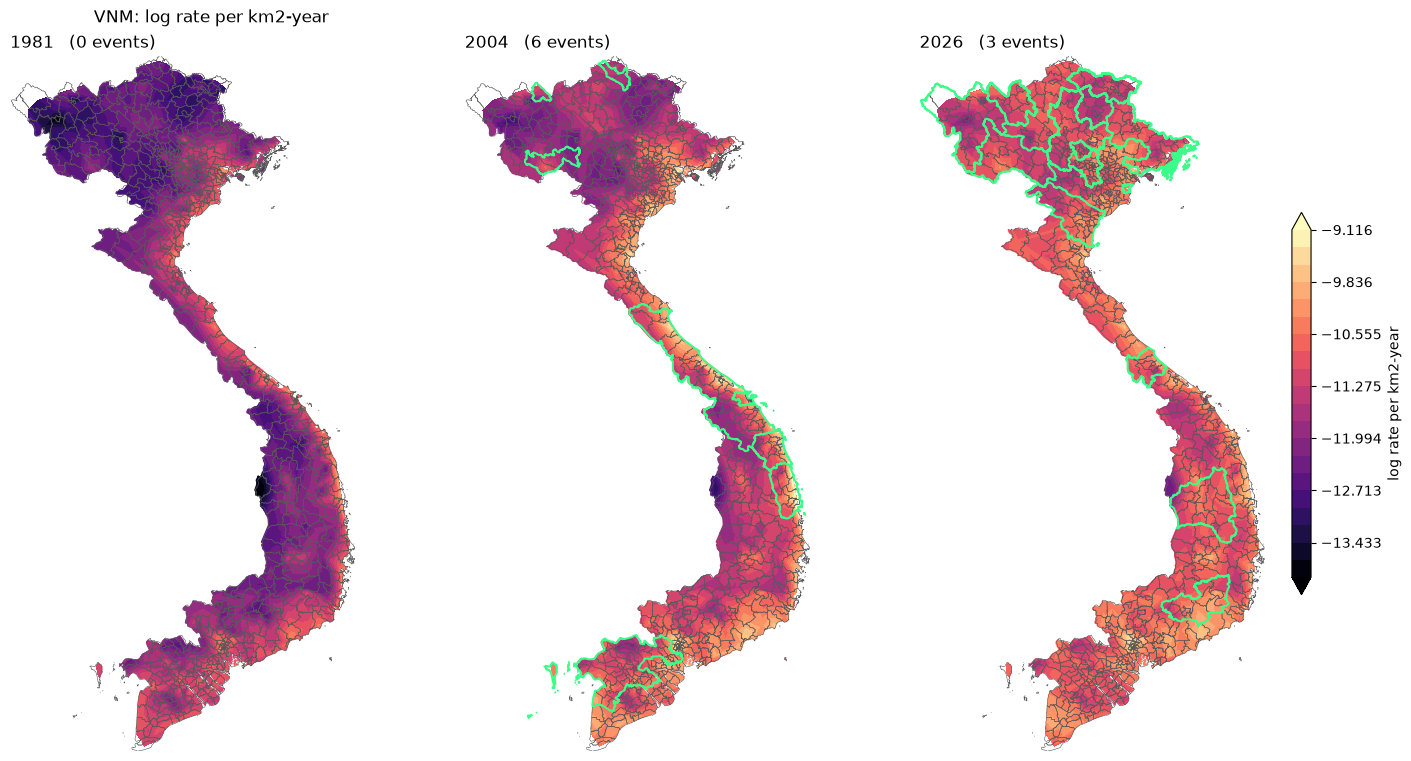

In [23]:
plot_country(lattice, "VNM", intensity_2, exposure="km2")

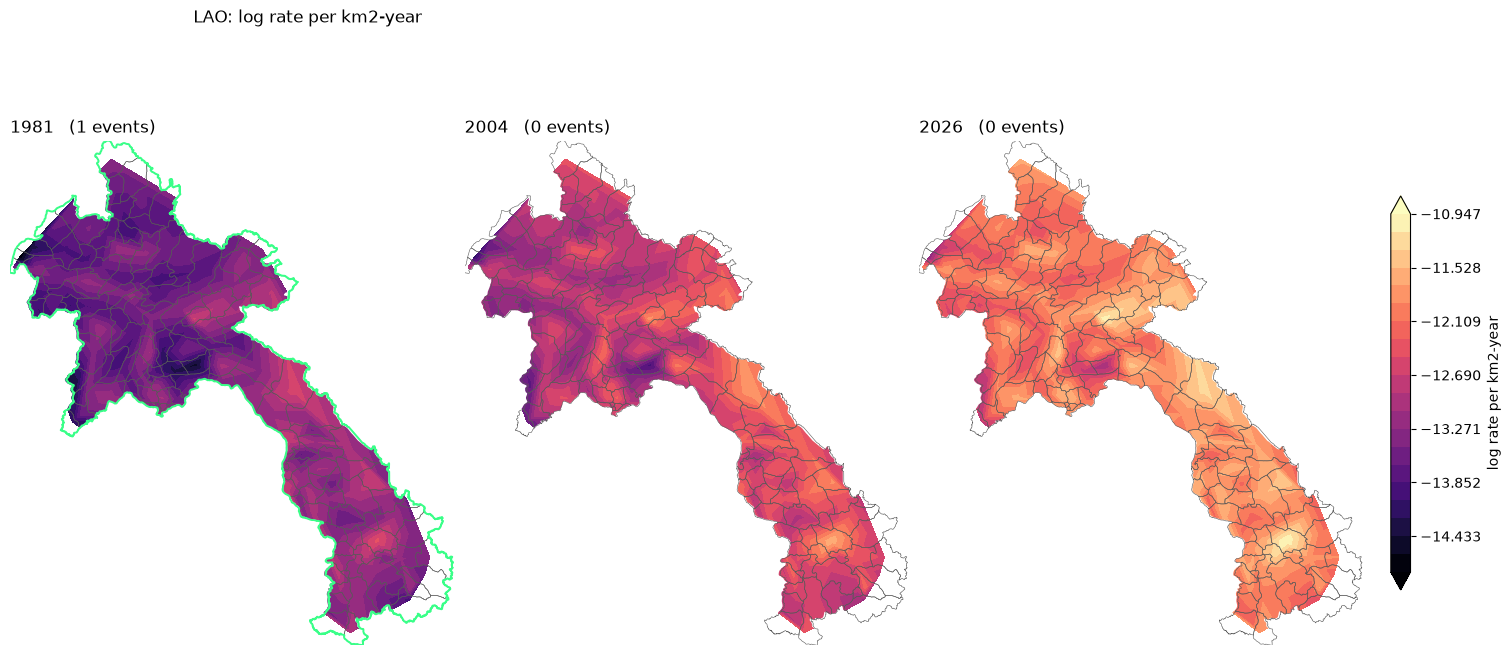

In [24]:
plot_country(lattice, "LAO", intensity_2, exposure="km2")

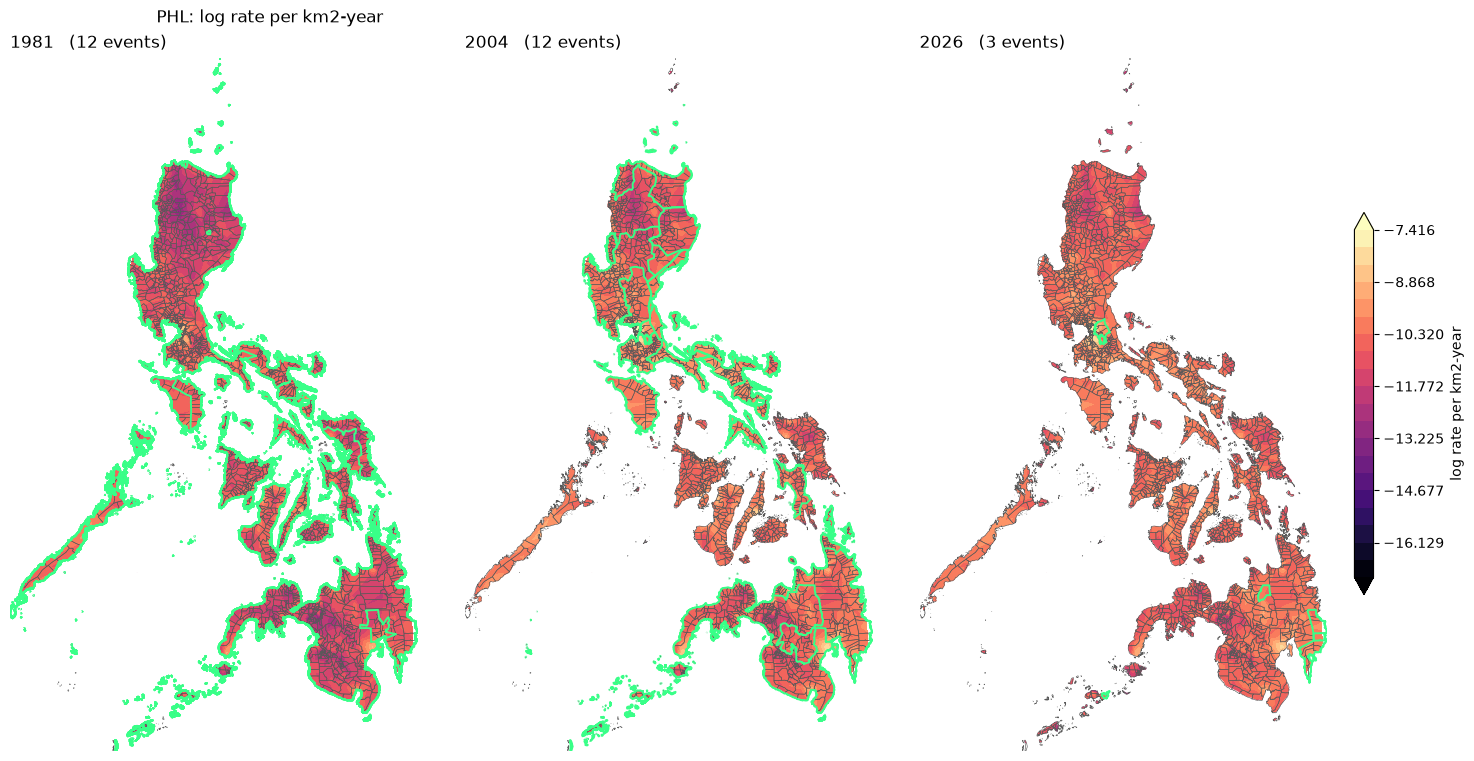

In [25]:
plot_country(lattice, "PHL", intensity_2, exposure="km2")

## The same field in outcome space

In [26]:
N_DRAWS = 1000
rng = np.random.default_rng(20260826)

# Expected events at an atom-year, which is the rate the maps above show times the atom's area.
expected_counts = intensity_2 * weights
scale_2 = np.sqrt(np.maximum(variance_2, 0.0))

sampled_counts = np.zeros_like(expected_counts, dtype=np.float64)
for _ in range(N_DRAWS):
    sampled_counts += rng.poisson(np.exp(rng.normal(mean_2, scale_2)) * weights)
sampled_counts /= N_DRAWS

pd.Series(
    {
        "draws": float(N_DRAWS),
        "sampled events, total": float(sampled_counts.sum()),
        "expected events, analytic": float(expected_counts.sum()),
        "events observed": float(observations.n_units),
        "expected events at an atom-year, median": float(np.median(expected_counts)),
        "expected events at an atom-year, largest": float(expected_counts.max()),
        "atom-years that never drew an event": float((sampled_counts == 0).mean()),
        "per-cell relative error, median": float(
            np.median(np.abs(sampled_counts - expected_counts) / expected_counts)
        ),
    },
    name="value",
).to_frame()

,value
draws,1000.00
"sampled events, total",1510.36
"expected events, analytic",1509.32
events observed,1509.00
"expected events at an atom-year, median",0.00
"expected events at an atom-year, largest",0.80
atom-years that never drew an event,0.18
"per-cell relative error, median",0.37


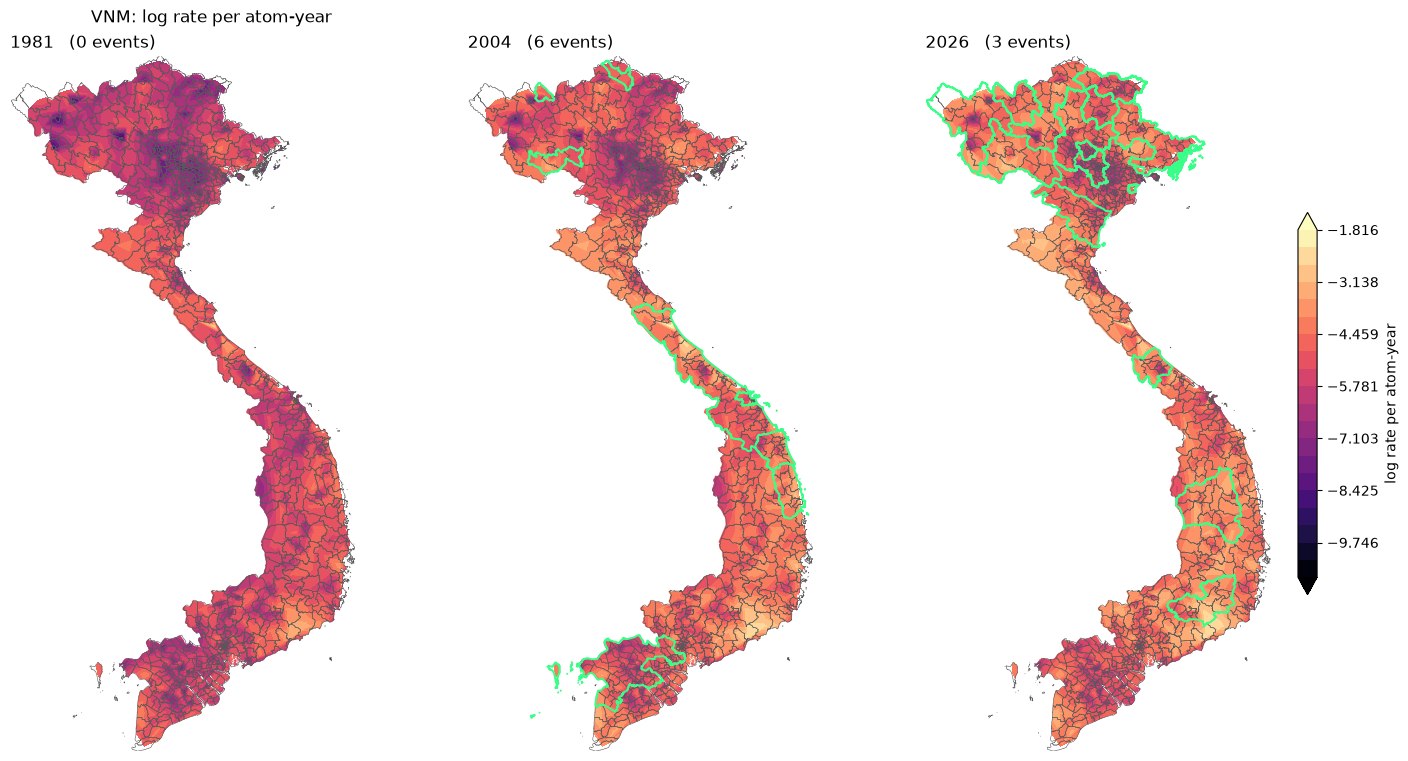

In [27]:
plot_country(lattice, "VNM", expected_counts, exposure="atom")

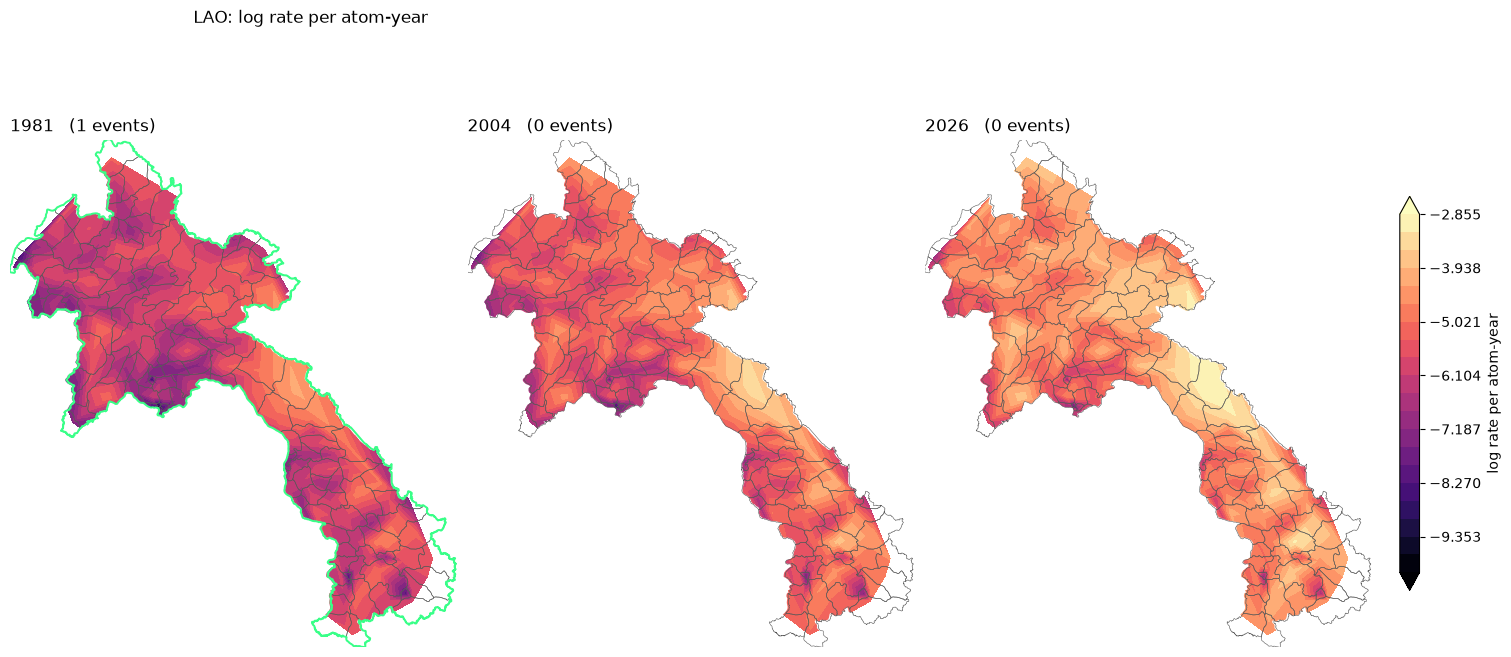

In [28]:
plot_country(lattice, "LAO", expected_counts, exposure="atom")

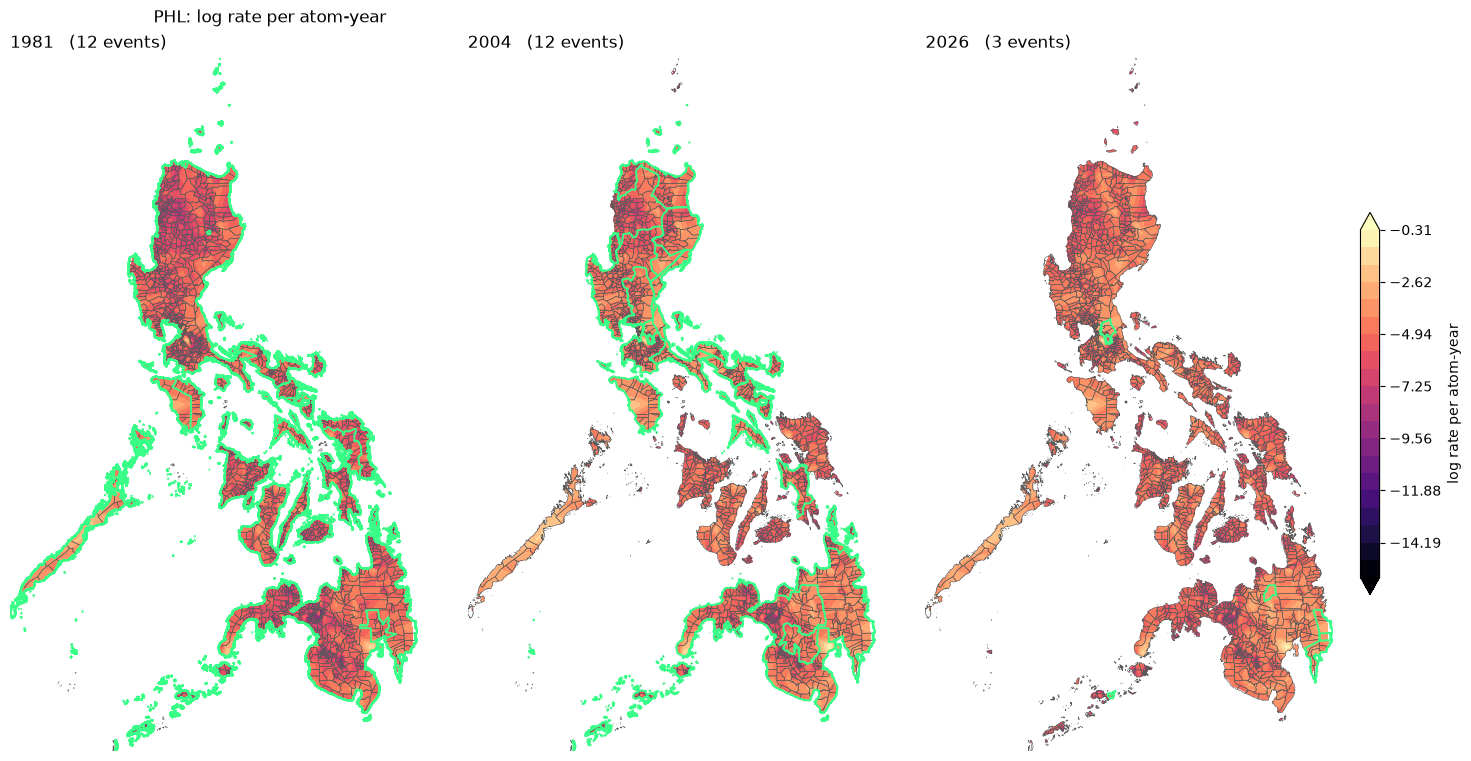

In [29]:
plot_country(lattice, "PHL", expected_counts, exposure="atom")

### Is the field higher where events were reported

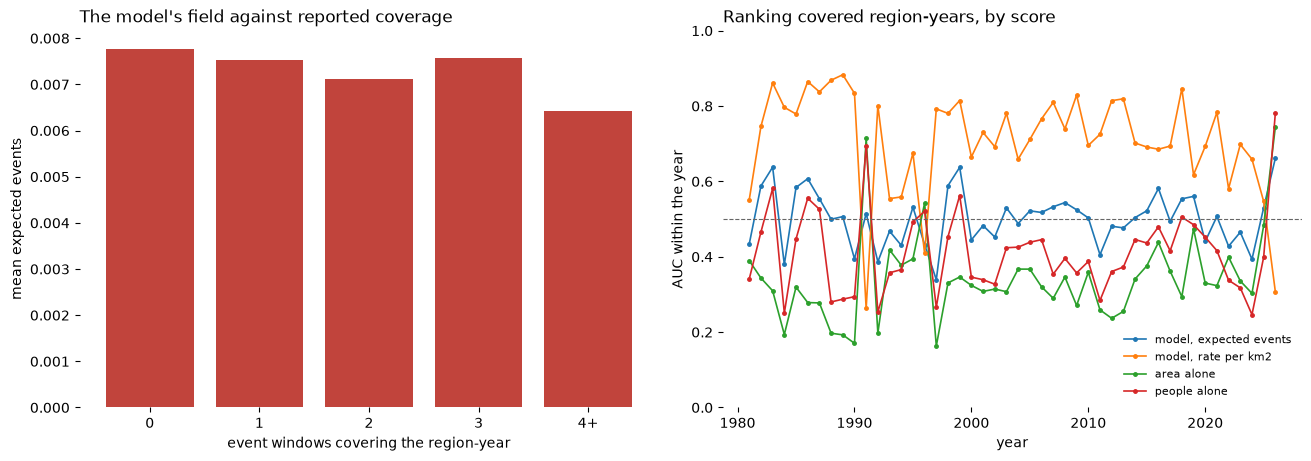

,"AUC, pooled","AUC within a year, median",covered / uncovered mean
"model, expected events",0.50,0.51,0.94
"model, rate per km2",0.67,0.73,1.87
area alone,0.36,0.33,0.48
people alone,0.42,0.41,0.73


In [31]:
MAX_COVERING_SHOWN = 4

# The atoms are the administrative units, so an atom-year is a region-year, and the question is
# whether the fitted field is higher at the region-years an event window actually reached. Area and
# population score the same target on their own, which says how much of any skill is the model's.
covering_events = np.asarray((observations.matrix != 0).sum(axis=0)).ravel()
covered = covering_events > 0
year_of_cell = np.repeat(lattice.years, lattice.n_atoms)

scores = {
    "model, expected events": expected_counts,
    "model, rate per km2": intensity_2,
    "area alone": np.tile(atom_area, lattice.n_years),
    "people alone": np.tile(atom_people, lattice.n_years),
}


def rank_auc(score, positive):
    """Probability the score ranks a covered region-year above an uncovered one."""
    order = np.argsort(score, kind="stable")
    ranks = np.empty(len(score), dtype=np.float64)
    ranks[order] = np.arange(1, len(score) + 1)
    n_positive, n_negative = positive.sum(), (~positive).sum()
    return (ranks[positive].sum() - n_positive * (n_positive + 1) / 2) / (n_positive * n_negative)


groups = np.clip(covering_events, 0, MAX_COVERING_SHOWN)
group_labels = [str(count) for count in range(MAX_COVERING_SHOWN)] + [f"{MAX_COVERING_SHOWN}+"]
mean_by_group = np.array([expected_counts[groups == count].mean() for count in range(MAX_COVERING_SHOWN + 1)])

years_with_both = [
    year for year in lattice.years if 0 < covered[year_of_cell == year].sum() < (year_of_cell == year).sum()
]
auc_by_year = {
    name: np.array([rank_auc(score[year_of_cell == year], covered[year_of_cell == year]) for year in years_with_both])
    for name, score in scores.items()
}

figure, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))

left.bar(group_labels, mean_by_group, color="#c1443c")
left.set_xlabel("event windows covering the region-year")
left.set_ylabel("mean expected events")
left.set_title("The model's field against reported coverage", loc="left")

for name, curve in auc_by_year.items():
    right.plot(years_with_both, curve, marker="o", markersize=2.5, linewidth=1.2, label=name)
right.axhline(0.5, color="0.4", linewidth=0.8, linestyle="--")
right.set_ylim(0.0, 1.0)
right.set_xlabel("year")
right.set_ylabel("AUC within the year")
right.set_title("Ranking covered region-years, by score", loc="left")
right.legend(frameon=False, fontsize=8, loc="lower right")

plt.show()

pd.DataFrame(
    {
        "AUC, pooled": {name: rank_auc(score, covered) for name, score in scores.items()},
        "AUC within a year, median": {name: float(np.median(curve)) for name, curve in auc_by_year.items()},
        "covered / uncovered mean": {
            name: float(score[covered].mean() / score[~covered].mean()) for name, score in scores.items()
        },
    }
).round(3)

In [32]:
# Pooling countries confounds the comparison: the Philippines has small units and many events,
# Laos large units and few. Scoring inside one country at a time removes that.
iso_of_cell = np.tile(lattice.iso_of_atom, lattice.n_years)

within_country = pd.DataFrame(
    {
        name: {
            iso: rank_auc(score[iso_of_cell == iso], covered[iso_of_cell == iso])
            for iso in sorted(set(iso_of_cell))
            if 0 < covered[iso_of_cell == iso].sum() < (iso_of_cell == iso).sum()
        }
        for name, score in scores.items()
    }
)
within_country["region-years covered"] = pd.Series(
    {iso: float(covered[iso_of_cell == iso].mean()) for iso in within_country.index}
)
within_country.round(3)

,"model, expected events","model, rate per km2",area alone,people alone,region-years covered
IDN,0.47,0.49,0.47,0.55,0.44
KHM,0.55,0.59,0.48,0.53,0.24
LAO,0.50,0.51,0.49,0.54,0.33
MMR,0.60,0.63,0.51,0.52,0.25
MYS,0.57,0.56,0.53,0.52,0.29
PHL,0.50,0.52,0.49,0.54,0.85
THA,0.52,0.50,0.52,0.49,0.48
TLS,0.59,0.61,0.52,0.49,0.05
VNM,0.54,0.49,0.54,0.45,0.54


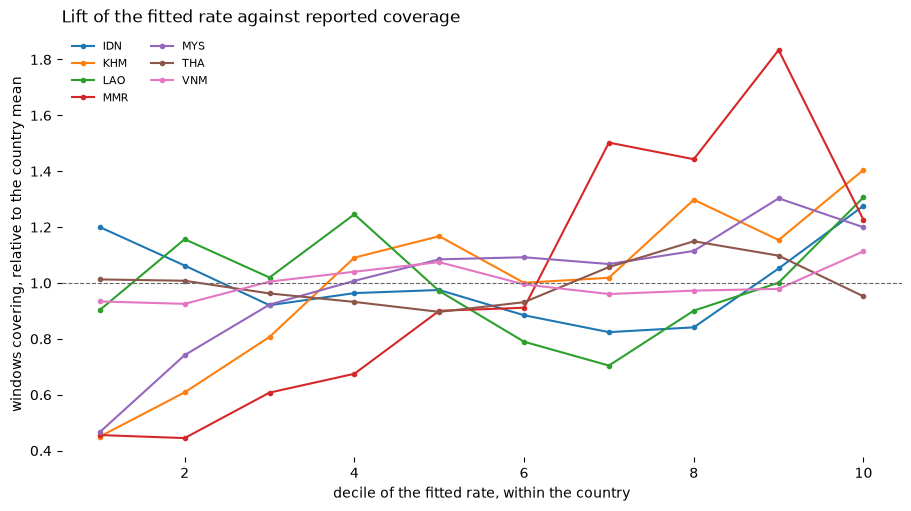

,"model, expected events","model, rate per km2",area alone,people alone,region-years covered
IDN,-0.05,-0.01,-0.06,0.10,0.44
KHM,0.07,0.14,-0.03,0.05,0.24
LAO,-0.01,0.01,-0.02,0.06,0.33
MMR,0.15,0.21,0.01,0.03,0.25
MYS,0.13,0.11,0.05,0.03,0.29
THA,0.02,-0.01,0.03,-0.02,0.48
VNM,0.08,-0.00,0.08,-0.09,0.54


In [33]:
COVERAGE_BAND = (0.20, 0.60)
N_BINS = 10

# Coverage near nought or one leaves nothing to rank, so the countries either side of the band are
# dropped and the target becomes the number of windows covering a region-year rather than whether
# any did.
coverage_by_country = pd.Series({iso: float(covered[iso_of_cell == iso].mean()) for iso in sorted(set(iso_of_cell))})
eligible = sorted(coverage_by_country[coverage_by_country.between(*COVERAGE_BAND)].index)


def average_ranks(values):
    """Ranks with ties averaged, so a target that is mostly zeros does not rank arbitrarily."""
    order = np.argsort(values, kind="stable")
    ranks = np.empty(len(values), dtype=np.float64)
    ranks[order] = np.arange(len(values), dtype=np.float64)
    _, start, counts = np.unique(values[order], return_index=True, return_counts=True)
    for begin, count in zip(start[counts > 1], counts[counts > 1], strict=True):
        tied = order[begin : begin + count]
        ranks[tied] = ranks[tied].mean()
    return ranks


def spearman(score, target):
    """Rank correlation between a score and a count target."""
    centered_score = average_ranks(score) - average_ranks(score).mean()
    centered_target = average_ranks(target) - average_ranks(target).mean()
    return float(
        centered_score @ centered_target / np.sqrt((centered_score @ centered_score) * (centered_target @ centered_target))
    )


figure, ax = plt.subplots(figsize=(9, 5))

for iso in eligible:
    here = iso_of_cell == iso
    score, target = intensity_2[here], covering_events[here]
    edges = np.quantile(score, np.linspace(0.0, 1.0, N_BINS + 1))
    bin_of = np.clip(np.searchsorted(edges, score, side="right") - 1, 0, N_BINS - 1)
    lift = np.array([target[bin_of == index].mean() for index in range(N_BINS)]) / target.mean()
    ax.plot(np.arange(1, N_BINS + 1), lift, marker="o", markersize=3, label=iso)

ax.axhline(1.0, color="0.4", linewidth=0.8, linestyle="--")
ax.set_xlabel("decile of the fitted rate, within the country")
ax.set_ylabel("windows covering, relative to the country mean")
ax.set_title("Lift of the fitted rate against reported coverage", loc="left")
ax.legend(frameon=False, ncols=2, fontsize=8)

plt.show()

pd.DataFrame(
    {name: {iso: spearman(score[iso_of_cell == iso], covering_events[iso_of_cell == iso]) for iso in eligible}
     for name, score in scores.items()}
).assign(**{"region-years covered": coverage_by_country[eligible]}).round(3)

## More inducing points, under the eigh factorization

At 250 points `K(Z, Z)` factors and at 500 it does not: the axes here are four compact standardized dimensions, so greedy points pack close together and the smallest eigenvalues cross zero. A ridge cannot recover a matrix whose spectrum has genuinely collapsed, but the symmetric square root can, by flooring it.

The cost is real. There is no GPU eigendecomposition under MLX, so every step synchronizes to the host, and the two factorizations define different whitened parameterizations, so nothing carries over from the fit above and this one starts fresh.

In [23]:
mx.clear_cache()
mx.reset_peak_memory()

N_INDUCING_3 = 1000
ADAM_STEPS_3 = 4000

inducing_3 = select_inducing(features_2, N_INDUCING_3, prior_kernel_2())[:, :N_KERNEL_DIMS_2]

started = time.perf_counter()
svgp_3, result_3 = fit_minibatch(
    features_2,
    observations,
    weights,
    inducing_3,
    mode="MLX",
    n_steps=ADAM_STEPS_3,
    n_windows=512,
    batch_size=100_000,
    optimizer_fn=annealed_adam(ADAM_STEPS_3, learning_rate=8e-3),
    model_fn=build_model_2,
    sqrt_method="eigh",
)
seconds_3 = time.perf_counter() - started
trained_3 = result_3.params

mean_3, variance_3 = ptgp.predict(svgp_3, features_2, result_3)
intensity_3 = np.exp(mean_3 + variance_3 / 2.0)

save_fit(
    result_3,
    "no_geography_1000_eigh",
    FITS_DIR,
    loss_last_500=float(result_3.result[-500:].mean()),
    noise_last_500=float(result_3.result[-500:].std()),
    n_inducing=N_INDUCING_3,
    placement="greedy conditional variance",
    sqrt_method="eigh",
    exposure="area, with population as a fitted exponent bounded to the unit interval",
    steps=ADAM_STEPS_3,
    floatX=FLOATX,
    mode="MLX",
    wall_clock_s=seconds_3,
)

trace_3 = pd.Series(result_3.result)


def fit_summary(inducing_count, seconds, trace, result, trained, intensity, peak_memory):
    """One column of the comparison, so the two are read off the same definitions."""
    return {
        "inducing points": float(inducing_count),
        "wall clock (s)": seconds,
        "MLX peak memory (GB)": peak_memory,
        "loss, first 100": float(trace.iloc[:100].mean()),
        "loss, last 500": float(trace.iloc[-500:].mean()),
        "per-step noise (sd)": float(trace.iloc[-500:].std()),
        "non-finite losses": float(np.sum(~np.isfinite(result.result))),
        "population exponent (beta)": float(trained["population_exponent"]),
        "country offsets, largest": float(np.abs(trained["country_offsets"]).max()),
        "hydro amplitude": trained["hydro_amplitude"],
        "coast amplitude": trained["coast_amplitude"],
        "hydro ls, time (yr)": trained["hydro_lengthscale_year"],
        "expected events": float(region.aggregate(intensity)[0]),
    }


pd.DataFrame(
    {
        "250, cholesky": fit_summary(N_INDUCING_2, seconds_2, trace_2, result_2, trained_2, intensity_2, np.nan),
        "1000, eigh": fit_summary(
            N_INDUCING_3, seconds_3, trace_3, result_3, trained_3, intensity_3, mx.get_peak_memory() / 1e9
        ),
    }
).round(3)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/4000 [00:00<?, ?it/s]

,"250, cholesky","1000, eigh"
inducing points,250.00,1000.00
wall clock (s),337.73,1499.24
MLX peak memory (GB),NaN,8.48
"loss, first 100",4235.13,5972.52
"loss, last 500",NaN,53893086873668906980177084416.00
per-step noise (sd),NaN,84784616451443606381037355008.00
non-finite losses,3033.00,1.00
population exponent (beta),0.58,0.52
"country offsets, largest",2.84,2.75
hydro amplitude,0.30,0.21


In [21]:
from ptgp.inducing import Points

# Before the axes were standardized, K(Z, Z) was indefinite from M=500 up and the Cholesky returned
# NaN. Same counts, same kernel, in the units the axes now carry.
compiled = {}
for count in (250, 500, 1000):
    points = select_inducing(features_2, count, prior_kernel_2())[:, :N_KERNEL_DIMS_2]
    padded = np.column_stack([points, np.zeros((count, features_2.shape[1] - N_KERNEL_DIMS_2))]).astype(FLOATX)
    rhs = pt.as_tensor(np.random.default_rng(0).normal(size=(count, 8)).astype(FLOATX))

    left, right = pt.matrix("left"), pt.matrix("right")
    Kuu = np.asarray(
        pytensor.function([left, right], prior_kernel_2()(left, right))(padded, padded), dtype=np.float64
    )
    values = np.linalg.eigvalsh(Kuu)

    row = {
        "smallest eigenvalue": values.min(),
        "condition number": values.max() / abs(values.min()),
    }
    for method in ("cholesky", "eigh"):
        variables = Points(Z=padded)
        variables.sqrt_method = method
        out = np.asarray(pytensor.function([], variables.Kuu_sqrt_solve(prior_kernel_2(), rhs))())
        row[f"{method} finite"] = bool(np.isfinite(out).all())

    compiled[count] = row

pd.DataFrame(compiled).T.rename_axis("inducing points")

,smallest eigenvalue,condition number,cholesky finite,eigh finite
inducing points,,,,
250,0.01,4674.76,True,True
500,0.00,22543.51,True,True
1000,0.00,115037.05,True,True


In [19]:
def eigh_solve(Kuu, rhs, floor_fraction=1e-6):
    """The eigh branch, in whatever precision Kuu arrives in."""
    values, vectors = np.linalg.eigh(Kuu)
    inverse_root = 1.0 / np.sqrt(np.maximum(values, floor_fraction * values.max()))

    return (vectors * inverse_root) @ (vectors.T @ rhs)


_left_2, _right_2 = pt.matrix("left"), pt.matrix("right")
_cross_2 = pytensor.function([_left_2, _right_2], prior_kernel_2()(_left_2, _right_2))

checks = {}
for count in (250, 1000):
    points = select_inducing(features_2, count, prior_kernel_2())[:, :N_KERNEL_DIMS_2]
    padded = np.column_stack([points, np.zeros((count, features_2.shape[1] - N_KERNEL_DIMS_2))]).astype(FLOATX)
    Kuu = np.asarray(_cross_2(padded, padded))
    rhs = np.random.default_rng(0).normal(size=(count, 8))

    for label, dtype in (("float32", np.float32), ("float64", np.float64)):
        values = np.linalg.eigvalsh(Kuu.astype(dtype))
        out = eigh_solve(Kuu.astype(dtype), rhs.astype(dtype))
        checks[(count, label)] = {
            "non-finite eigenvalues": float((~np.isfinite(values)).sum()),
            "smallest eigenvalue": float(values.min()),
            "under the floor": float((values < 1e-6 * values.max()).sum()),
            "solve finite": bool(np.isfinite(out).all()),
            "max|out|": float(np.abs(out[np.isfinite(out)]).max()) if np.isfinite(out).any() else np.inf,
        }

pd.DataFrame(checks).T.rename_axis(["inducing points", "precision"])

non-finite eigenvalues smallest eigenvalue  \
inducing points precision                                              
250             float32                     0.00                0.01   
                float64                     0.00                0.01   
1000            float32                     0.00               -0.01   
                float64                     0.00               -0.01   

                          under the floor solve finite max|out|  
inducing points precision                                        
250             float32              0.00         True    20.76  
                float64              0.00         True    20.76  
1000            float32            217.00         True   187.46  
                float64            217.00         True   187.46

In [17]:
SWEEP_STEPS = 2000

sweep_inducing = select_inducing(features_2, 250, prior_kernel_2())[:, :N_KERNEL_DIMS_2]

rates = {}
for rate in (5e-3, 2e-2, 5e-2, 1e-1):
    mx.clear_cache()
    started = time.perf_counter()
    _, swept = fit_minibatch(
        features_2,
        observations,
        weights,
        sweep_inducing,
        mode="MLX",
        n_steps=SWEEP_STEPS,
        n_windows=512,
        batch_size=100_000,
        optimizer_fn=annealed_adam(SWEEP_STEPS, learning_rate=rate),
        model_fn=build_model_2,
    )
    trace = pd.Series(swept.result)
    half = SWEEP_STEPS // 2

    rates[rate] = {
        "loss, last 200": float(trace.iloc[-200:].mean()),
        "loss at the halfway mark": float(trace.iloc[half - 100 : half + 100].mean()),
        "still moving in the last half": float(trace.iloc[half - 100 : half + 100].mean() - trace.iloc[-200:].mean()),
        "per-step noise (sd)": float(trace.iloc[-200:].std()),
        "non-finite losses": float(np.sum(~np.isfinite(swept.result))),
        "population exponent (beta)": float(swept.params["population_exponent"]),
        "seconds": time.perf_counter() - started,
    }

# Rounding the frame rounds its index too, so 0.005 prints as 0.01.
pd.DataFrame(rates).T.rename_axis("learning rate").round(2)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/2000 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/2000 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/2000 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/2000 [00:00<?, ?it/s]

,"loss, last 200",loss at the halfway mark,still moving in the last half,per-step noise (sd),non-finite losses,population exponent (beta),seconds
learning rate,,,,,,,
0.01,3596.27,3631.38,35.11,113.41,0.00,0.51,187.30
0.02,NaN,NaN,NaN,NaN,1934.00,-0.10,179.96
0.05,NaN,NaN,NaN,NaN,1987.00,-0.30,222.57
0.10,NaN,NaN,NaN,NaN,1996.00,-0.32,182.01


In [27]:
BREAK_STEPS = 1500

break_inducing = select_inducing(features_2, 250, prior_kernel_2())[:, :N_KERNEL_DIMS_2]

where_it_breaks = {}
for mode in ("FAST_RUN", "MLX"):
    _, run = fit_minibatch(
        features_2,
        observations,
        weights,
        break_inducing,
        mode=mode,
        n_steps=BREAK_STEPS,
        n_windows=512,
        batch_size=100_000,
        optimizer_fn=annealed_adam(BREAK_STEPS, learning_rate=8e-3),
        model_fn=build_model_2,
    )
    bad = ~np.isfinite(run.result)
    finite = run.result[~bad]

    where_it_breaks[mode] = {
        "non-finite losses": float(bad.sum()),
        "first non-finite step": float(np.argmax(bad)) if bad.any() else -1.0,
        "all non-finite consecutive after that": bool(bad[np.argmax(bad) :].all()) if bad.any() else True,
        "best finite loss": float(finite.min()) if finite.size else np.nan,
        "population exponent (beta)": float(run.params["population_exponent"]),
    }

pd.DataFrame(where_it_breaks).T.rename_axis("backend")

adam:   0%|          | 0/1500 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/1500 [00:00<?, ?it/s]

,non-finite losses,first non-finite step,all non-finite consecutive after that,best finite loss,population exponent (beta)
backend,,,,,
FAST_RUN,0.00,-1.00,True,3264.96,0.40
MLX,0.00,-1.00,True,3260.25,0.40


In [20]:
from ptgp.optim.training import compile_scipy_diagnostics

from svgp_support import MinibatchTerms, build_minibatch_objective, poisson_intercept

# Rebuilt so the diagnostic graph carries the same batch state the objective does, then evaluated at
# the parameters the dead fit froze on. Its theta is the layout compile_scipy_objective writes, and
# compile_scipy_diagnostics reads the same one.
frozen_theta = np.load(FITS_DIR / "no_geography.npz", allow_pickle=True)["theta"]

diag_inducing = select_inducing(features_2, 250, prior_kernel_2())[:, :N_KERNEL_DIMS_2]
diag_model, diag_svgp = build_model_2(
    features_2,
    diag_inducing,
    intercept_init=poisson_intercept(observations.n_units, float(weights.astype(np.float64).sum())),
)
diag_load_batch, _, diag_terms, diag_batch_state = build_minibatch_objective(
    observations, features_2, weights, len(diag_inducing), batch_size=100_000, n_draws=16
)

with diag_model:
    evaluate_terms = compile_scipy_diagnostics(
        diag_terms,
        diag_svgp,
        pt.matrix("X", shape=(None, features_2.shape[1])),
        pt.vector("y", shape=(512,)),
        model=diag_model,
        compile_kwargs={"mode": "FAST_RUN"},
    )

# Several batches: a term that is only sometimes non-finite is a different fault from one that
# always is, and the frozen parameters are the same for all of them.
diag_rng = np.random.default_rng(0)
readings = {}
for attempt in range(4):
    batch_features, batch_counts = diag_load_batch(diag_rng, 512)
    values = evaluate_terms(frozen_theta, batch_features, batch_counts)
    readings[f"batch {attempt}"] = dict(zip(MinibatchTerms._fields, np.asarray(values, dtype=float), strict=True))

pd.DataFrame(readings)

,batch 0,batch 1,batch 2,batch 3
elbo,-3609.53,-4173.13,-4243.19,-4023.33
window_term,-2115.97,-2680.85,-2762.55,-2538.36
region_term,1446.52,1445.23,1433.58,1437.93
kl,47.05,47.05,47.05,47.05
smallest_window_total,0.69,0.28,0.34,0.16
windows_at_zero,0.00,0.00,0.00,0.00
smallest_log_intensity,-7.90,-9.11,-8.33,-9.13
largest_absolute_mean,16.37,16.34,16.36,16.36
smallest_independent_variance,-0.01,-0.01,-0.01,-0.01
largest_independent_variance,0.01,0.01,0.01,0.01


In [16]:
# Same frozen parameters, same batch, both backends. The fit that died ran on MLX; the diagnostic
# above ran on FAST_RUN and found nothing wrong, so the backends are the remaining difference.
backend_terms = {}
for mode in ("FAST_RUN", "MLX"):
    with diag_model:
        evaluate = compile_scipy_diagnostics(
            diag_terms,
            diag_svgp,
            pt.matrix("X", shape=(None, features_2.shape[1])),
            pt.vector("y", shape=(512,)),
            model=diag_model,
            compile_kwargs={"mode": mode},
        )

    fixed_rng = np.random.default_rng(0)
    batch_features, batch_counts = diag_load_batch(fixed_rng, 512)
    values = np.asarray(evaluate(frozen_theta, batch_features, batch_counts), dtype=float)
    backend_terms[mode] = dict(zip(MinibatchTerms._fields, values, strict=True))

pd.DataFrame(backend_terms)

,FAST_RUN,MLX
elbo,-3757.25,-3753.04
window_term,-2164.66,-2159.13
region_term,1545.54,1546.86
kl,47.05,47.05
smallest_window_total,0.69,0.67
windows_at_zero,0.00,0.00
smallest_log_intensity,-7.75,-7.76
largest_absolute_mean,16.68,16.68
smallest_independent_variance,-0.00,-0.01
largest_independent_variance,0.01,0.01


In [17]:
# The training loss is -ELBO minus the model's prior logp, and the terms above cover only the ELBO.
# The value variables are the leading block of theta, in the order the model created them.
frozen_point = diag_model.initial_point()

offset = 0
for value_var in diag_model.continuous_value_vars:
    template = frozen_point[value_var.name]
    frozen_point[value_var.name] = (
        frozen_theta[offset : offset + template.size].reshape(template.shape).astype(template.dtype)
    )
    offset += template.size

prior_terms = diag_model.compile_logp(sum=False)(frozen_point)
named = {rv.name: float(np.sum(value)) for rv, value in zip(diag_model.basic_RVs, prior_terms, strict=True)}
named["TOTAL"] = float(sum(named.values()))

pd.DataFrame(
    {
        "prior logp": named,
        "value at theta": {
            **{v.name: float(np.ravel(frozen_point[v.name])[0]) for v in diag_model.continuous_value_vars},
            "TOTAL": np.nan,
        },
    }
)

,prior logp,value at theta
intercept,-2.68,-12.73
hydro_amplitude,-0.65,NaN
hydro_lengthscale_to_river,-0.89,NaN
hydro_lengthscale_river_flow,-0.41,NaN
hydro_lengthscale_year,-0.65,NaN
coast_amplitude,-0.39,NaN
coast_lengthscale_to_coast,-0.43,NaN
coast_lengthscale_year,-0.80,NaN
population_exponent,-1.26,NaN
country_offsets,-16.92,0.97


In [25]:
first_nan = {"radius": 5}

_, capture_result = fit_minibatch(
    features_2,
    observations,
    weights,
    diag_inducing,
    mode="MLX",
    n_steps=4000,
    n_windows=512,
    batch_size=100_000,
    optimizer_fn=annealed_adam(4000, learning_rate=8e-3),
    model_fn=build_model_2,
    capture=first_nan,
)

capture_trace = capture_result.result
pd.Series(
    {
        "non-finite losses": float(np.sum(~np.isfinite(capture_trace))),
        "step it first went non-finite": float(first_nan.get("step", -1)),
        "steps captured in the window": float(len(first_nan.get("window", []))),
        "captured theta is finite": float(bool(np.isfinite(first_nan["theta"]).all())),
    },
    name="value",
).to_frame()

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: The optimizer produced non-finite updates on 6 consecutive steps. Each was thrown away, so the parameters are the ones from before the first of them, and training has made no progress since. Lower the learning rate, clip the gradients, or look for a term in the loss that can overflow; raise `max_consecutive_skips`, or set it to None, to keep skipping instead.) as MLX tracing would remove it.
  return dispatch(args[0].__class__

adam:   0%|          | 0/4000 [00:00<?, ?it/s]

,value
non-finite losses,2757.00
step it first went non-finite,1243.00
steps captured in the window,11.00
captured theta is finite,1.00


In [22]:
captured_theta = first_nan["theta"]

# The batch state the fit was on lives in that fit's own shared variables and cannot be reached from
# here, so these are fresh batches. If the parameters alone are pathological it shows up on any of
# them; if every one comes back finite, the state is fine and the batch was the difference.
captured_readings = {}
captured_rng = np.random.default_rng(1)
for attempt in range(4):
    batch_features, batch_counts = diag_load_batch(captured_rng, 512)
    values = np.asarray(evaluate_terms(captured_theta, batch_features, batch_counts), dtype=float)
    captured_readings[f"batch {attempt}"] = dict(zip(MinibatchTerms._fields, values, strict=True))

captured_point = diag_model.initial_point()
offset = 0
for value_var in diag_model.continuous_value_vars:
    template = captured_point[value_var.name]
    captured_point[value_var.name] = (
        captured_theta[offset : offset + template.size].reshape(template.shape).astype(template.dtype)
    )
    offset += template.size

prior_total = float(np.sum([np.sum(term) for term in diag_model.compile_logp(sum=False)(captured_point)]))

frame = pd.DataFrame(captured_readings)
frame.loc["prior logp (all batches)"] = prior_total
frame.loc["training loss = -elbo - prior"] = -frame.loc["elbo"] - prior_total
frame.round(3)

,batch 0,batch 1,batch 2,batch 3
elbo,-3580.19,-3409.80,-3675.05,-3669.41
window_term,-2013.38,-1837.96,-2098.05,-2098.84
region_term,1523.76,1528.79,1533.95,1527.52
kl,43.05,43.05,43.05,43.05
smallest_window_total,0.13,0.59,0.58,0.13
windows_at_zero,0.00,0.00,0.00,0.00
smallest_log_intensity,-9.34,-7.76,-7.79,-9.32
largest_absolute_mean,16.10,16.10,16.10,16.10
smallest_independent_variance,-0.01,-0.01,-0.01,-0.01
largest_independent_variance,0.01,0.01,0.01,0.01


In [26]:
# Each step of the window: what the fit reported, and what the objective actually is at the
# parameters that step reported from. The batch is held fixed across rows so the only thing varying
# is the state, and the failing batch is the one loaded.
for name, value in first_nan["batch_state"].items():
    diag_batch_state[name].set_value(value)

failing_features, failing_counts = first_nan["batch"]
reference = first_nan["theta"]

rows = []
for position, theta, reported in first_nan["window"]:
    values = np.asarray(evaluate_terms(theta, failing_features, failing_counts), dtype=float)
    terms = dict(zip(MinibatchTerms._fields, values, strict=True))
    rows.append(
        {
            "step": position,
            "loss the fit reported": reported,
            "elbo at that theta": terms["elbo"],
            "smallest window total": terms["smallest_window_total"],
            "windows at zero": terms["windows_at_zero"],
            "theta finite": bool(np.isfinite(theta).all()),
            "distance from the theta at the first NaN": float(np.abs(theta - reference).max()),
        }
    )

pd.DataFrame(rows).set_index("step").round(6)

,loss the fit reported,elbo at that theta,smallest window total,windows at zero,theta finite,distance from the theta at the first NaN
step,,,,,,
1238,3564.91,-3455.02,0.87,0.00,True,0.06
1239,3519.22,-3460.03,0.90,0.00,True,0.05
1240,3503.38,-3456.28,0.90,0.00,True,0.04
1241,3464.73,-3458.93,0.87,0.00,True,0.02
1242,3575.07,-3458.02,0.82,0.00,True,0.01
1243,NaN,NaN,NaN,0.00,True,0.00
1244,NaN,NaN,NaN,0.00,True,0.00
1245,NaN,NaN,NaN,0.00,True,0.00
1246,NaN,NaN,NaN,0.00,True,0.00


In [27]:
# Every term across the step that flips, on the batch that flips it. The last finite state and the
# first non-finite one differ by 0.01 in one coordinate, so whichever term turns over between these
# two columns is the one with the cliff in it.
crossing = {}
for position, theta, reported in first_nan["window"]:
    if position not in (first_nan["step"] - 1, first_nan["step"]):
        continue
    values = np.asarray(evaluate_terms(theta, failing_features, failing_counts), dtype=float)
    crossing[f"step {position}"] = dict(zip(MinibatchTerms._fields, values, strict=True))

frame = pd.DataFrame(crossing)
frame.loc["_"] = np.nan

# Which coordinates actually moved over that step, and by how much.
last_good = next(t for p, t, _ in first_nan["window"] if p == first_nan["step"] - 1)
moved = np.abs(first_nan["theta"] - last_good)
frame.loc["largest coordinate move"] = float(moved.max())
frame.loc["index of that coordinate"] = float(np.argmax(moved))
frame.loc["coordinates that moved at all"] = float((moved > 0).sum())

frame.round(6)

,step 1242,step 1243
elbo,-3458.02,NaN
window_term,-1875.51,NaN
region_term,1536.63,NaN
kl,45.88,46.04
smallest_window_total,0.82,NaN
windows_at_zero,0.00,0.00
smallest_log_intensity,-7.34,NaN
largest_absolute_mean,16.28,NaN
smallest_independent_variance,-0.00,NaN
largest_independent_variance,0.01,NaN


In [28]:
# The hyperparameters are the leading block of theta, in transformed space: the intercept, then
# logs of the amplitudes and lengthscales. Rebuilding K(Z, Z) at the last finite state and the first
# non-finite one says whether the factorization is what turned over.
HYPER_ORDER = (
    "intercept",
    "hydro_amplitude",
    "hydro_lengthscale_to_river",
    "hydro_lengthscale_river_flow",
    "hydro_lengthscale_year",
    "coast_amplitude",
    "coast_lengthscale_to_coast",
    "coast_lengthscale_year",
)

padded_inducing = np.column_stack(
    [diag_inducing, np.zeros((len(diag_inducing), features_2.shape[1] - N_KERNEL_DIMS_2))]
).astype(FLOATX)

spectrum = {}
for position, theta, _ in first_nan["window"]:
    if position not in (first_nan["step"] - 1, first_nan["step"]):
        continue

    named = dict(zip(HYPER_ORDER, theta[: len(HYPER_ORDER)], strict=True))
    values = {key: float(np.exp(value)) for key, value in named.items() if key != "intercept"}

    kernel_here = values["hydro_amplitude"] ** 2 * Matern32(
        input_dim=features_2.shape[1],
        ls=np.array(
            [values["hydro_lengthscale_to_river"], values["hydro_lengthscale_river_flow"], values["hydro_lengthscale_year"]],
            dtype=FLOATX,
        ),
        active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
    ) + values["coast_amplitude"] ** 2 * Matern32(
        input_dim=features_2.shape[1],
        ls=np.array([values["coast_lengthscale_to_coast"], values["coast_lengthscale_year"]], dtype=FLOATX),
        active_dims=[TO_COAST, YEAR],
    )

    left, right = pt.matrix("left"), pt.matrix("right")
    Kuu = np.asarray(
        pytensor.function([left, right], kernel_here(left, right))(padded_inducing, padded_inducing), dtype=np.float64
    )
    eigenvalues = np.linalg.eigvalsh(Kuu)
    ridge = InducingVariables._JITTER_MARGIN * np.finfo(np.float32).eps * len(Kuu) * np.mean(np.diag(Kuu))

    spectrum[f"step {position}"] = {
        **{key: round(value, 4) for key, value in values.items()},
        "smallest eigenvalue": eigenvalues.min(),
        "ridge available": ridge,
        "ridge covers it": bool(ridge + eigenvalues.min() > 0),
    }

pd.DataFrame(spectrum)

,step 1242,step 1243
hydro_amplitude,0.41,0.41
hydro_lengthscale_to_river,4.22,4.22
hydro_lengthscale_river_flow,2.34,2.33
hydro_lengthscale_year,15.26,15.28
coast_amplitude,0.43,0.43
coast_lengthscale_to_coast,2.36,2.36
coast_lengthscale_year,15.05,15.01
smallest eigenvalue,0.00,-0.00
ridge available,0.00,0.00
ridge covers it,True,False


In [30]:
# Where the edge actually is. The other hyperparameters are held at the values the Cholesky run had
# when it died; only the temporal lengthscales move, since that is what drifted.
def smallest_eigenvalue_at(temporal, spatial_ls=(4.22, 2.33, 2.36), amplitudes=(0.41, 0.43)):
    """Smallest eigenvalue of K(Z, Z), and whether the ridge still covers it."""
    river, flow, coast = spatial_ls
    hydro, coastal = amplitudes

    kernel_here = hydro**2 * Matern32(
        input_dim=features_2.shape[1],
        ls=np.array([river, flow, temporal], dtype=FLOATX),
        active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
    ) + coastal**2 * Matern32(
        input_dim=features_2.shape[1],
        ls=np.array([coast, temporal], dtype=FLOATX),
        active_dims=[TO_COAST, YEAR],
    )

    left, right = pt.matrix("left"), pt.matrix("right")
    Kuu = np.asarray(
        pytensor.function([left, right], kernel_here(left, right))(padded_inducing, padded_inducing),
        dtype=np.float64,
    )
    values = np.linalg.eigvalsh(Kuu)
    ridge = InducingVariables._JITTER_MARGIN * np.finfo(np.float32).eps * len(Kuu) * np.mean(np.diag(Kuu))

    return {
        "smallest eigenvalue": values.min(),
        "condition number": values.max() / abs(values.min()),
        "cholesky survives": bool(ridge + values.min() > 0),
    }


edge = {years: smallest_eigenvalue_at(years) for years in (2, 4, 6, 8, 10, 12, 15, 20)}
pd.DataFrame(edge).T.rename_axis("temporal lengthscale (yr)")

,smallest eigenvalue,condition number,cholesky survives
temporal lengthscale (yr),,,
2,-0.03,202.98,False
4,-0.00,22029.16,False
6,-0.00,111721.47,False
8,0.00,10175.99,True
10,0.00,35679.87,True
12,0.00,23351.61,True
15,0.00,128241.81,True
20,0.00,142582.13,True


In [15]:
exponent = mean_2 + variance_2 / 2.0

pd.Series(
    {
        "mean, smallest": float(np.nanmin(mean_2)),
        "mean, largest": float(np.nanmax(mean_2)),
        "variance, smallest": float(np.nanmin(variance_2)),
        "variance, largest": float(np.nanmax(variance_2)),
        "variance entries below zero": float((variance_2 < 0).sum()),
        "exponent, largest": float(np.nanmax(exponent)),
        "exponent above the float64 limit (709)": float((exponent > 709).sum()),
        "non-finite in mean": float((~np.isfinite(mean_2)).sum()),
        "non-finite in variance": float((~np.isfinite(variance_2)).sum()),
        "atom-years": float(len(mean_2)),
    },
    name="value",
).to_frame()

,value
"mean, smallest",-18.90
"mean, largest",-8.48
"variance, smallest",0.06
"variance, largest",94257.61
variance entries below zero,0.00
"exponent, largest",47113.73
exponent above the float64 limit (709),6376.00
non-finite in mean,0.00
non-finite in variance,0.00
atom-years,201802.00


In [17]:
from ptgp.inducing import Points

# At the hyperparameters the diverged fit ended on, not the prior's. The floor sets how far the
# whitening may amplify a near-null direction, and that amplification lands squared in the
# posterior variance.
fitted_kernel = trained_2["hydro_amplitude"] ** 2 * Matern32(
    input_dim=features_2.shape[1],
    ls=np.array(
        [
            trained_2["hydro_lengthscale_to_river"],
            trained_2["hydro_lengthscale_river_flow"],
            trained_2["hydro_lengthscale_year"],
        ],
        dtype=FLOATX,
    ),
    active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
) + trained_2["coast_amplitude"] ** 2 * Matern32(
    input_dim=features_2.shape[1],
    ls=np.array(
        [trained_2["coast_lengthscale_to_coast"], trained_2["coast_lengthscale_year"]], dtype=FLOATX
    ),
    active_dims=[TO_COAST, YEAR],
)

padded_2 = np.column_stack(
    [inducing_2, np.zeros((len(inducing_2), features_2.shape[1] - N_KERNEL_DIMS_2))]
).astype(FLOATX)

_left, _right = pt.matrix("left"), pt.matrix("right")
_cross = pytensor.function([_left, _right], fitted_kernel(_left, _right))

Kuu_now = np.asarray(_cross(padded_2, padded_2), dtype=np.float64)
values, vectors = np.linalg.eigh(Kuu_now)

sample_rows = np.random.default_rng(0).choice(len(features_2), size=20_000, replace=False)
cross_sample = np.asarray(_cross(padded_2, features_2[sample_rows]), dtype=np.float64)

sweep = {}
for floor_fraction in (1e-6, 1e-5, 1e-4, 1e-3, 1e-2):
    inverse_root = 1.0 / np.sqrt(np.maximum(values, floor_fraction * values.max()))
    whitened = (vectors * inverse_root) @ (vectors.T @ cross_sample)

    sweep[f"{floor_fraction:.0e}"] = {
        "eigenvalues at the floor": float((values < floor_fraction * values.max()).sum()),
        "largest amplification": float(inverse_root.max()),
        "largest sum of squares per row": float((whitened**2).sum(axis=0).max()),
    }

pd.DataFrame(sweep).T.rename_axis("floor, as a fraction of the largest eigenvalue").round(2)

,eigenvalues at the floor,largest amplification,largest sum of squares per row
"floor, as a fraction of the largest eigenvalue",,,
1e-06,0.00,40.25,0.53
1e-05,0.00,40.25,0.53
1e-04,0.00,40.25,0.53
1e-03,1.00,39.26,0.51
1e-02,2.00,12.41,0.15


In [18]:
# The pre-training check from the bad_priors pitfall: Kuu at the prior median, before any fitting.
# select_inducing discards this second return value, which is where these numbers live.
prior_sample = features_2[np.random.default_rng(0).choice(len(features_2), size=20_000, replace=False)]

_, prior_diagnostics = greedy_variance_init(prior_sample, 250, prior_kernel_2())
print(repr(prior_diagnostics))

M                 : 250
variance explained: 97.8%
min eigenvalue    : 0.00933
max eigenvalue    : 40.6
condition number  : 4.35e+03
eigs < 1e-04     : 0
